# <font color="red">**Higher-Dimensional Optical Data Visualization Challenge**</font>

## Composition → spectrum → measurement context

### The problem

Optical libraries are difficult to visualize because every sample has a composition,
a full spectrum, a measurement geometry, and sometimes an elapsed-time history. A
collection of separate plots makes comparisons slow, but forcing everything into one
crowded plot can hide the spectral evidence.

> **Can we make all of those variables easier to explore without hiding the spectra
> or compressing the experiment into a single unexplained score?**

### The approach

Like the example EELS hackathon notebook, this notebook follows one linear pattern:

1. inspect the data and its dimensions;
2. run one complete, deliberately simple worked example;
3. modify that baseline in a clearly marked challenge cell;
4. test whether a new user can answer the stated scientific question.

### Choose one challenge

1. **Challenge 1 — Quaternary System:** connect FA/Cs/Rb/DMA composition and I/Br variation to
   Top PL, Bottom PL, and absorbance.
2. **Challenge 2 — RP-Additive System:** connect 3AMP/FAPbI3 host composition and nominal MACl
   level to Top/Bottom PL over 0–380 minutes.

### Your final result

- one visualization that answers a specific scientific question;
- the full spectral evidence remains reachable or visible;
- one sentence explaining what became easier to see and one possible misinterpretation.

The worked examples are deliberately simple baselines not
the expected final answer.


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kbarakati/athena_camm_hackathon/blob/k4my4r/docs/day_19_02102026/Higher_Dimensional_Optical_Data_Hackathon.ipynb)

<h2><font color="purple">1.</font> Download and Load the Data</h2>

Run the next cells from top to bottom. One public Google Drive folder contains both
challenge folders. The download cell is safe to rerun: it reuses a verified local copy
and only downloads again when files are missing or changed.


In [1]:
# @title 1. Install and import the small analysis stack
%pip -q install "gdown==6.4.1" "pyarrow>=14" "plotly>=5.22"


Note: you may need to restart the kernel to use updated packages.


In [2]:

from html import escape
from pathlib import Path
import hashlib
import shutil
import sys

import gdown
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from IPython.display import FileLink, HTML, Markdown, display


In [3]:
# # @title 2. Download both challenge folders from Google Drive
# DRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/16YfPjFdZHgW3hkC0QBLrCS9um2C6aK5q?usp=drive_link"
# IN_COLAB = "google.colab" in sys.modules
# DATA_ROOT = Path(
#     "/content/higher_dimensional_optical_data"
#     if IN_COLAB else "./.higher_dimensional_optical_data"
# ).resolve()
# STAGING_ROOT = DATA_ROOT.with_name(DATA_ROOT.name + "_download")

# REMOTE_QUATERNARY_FOLDER = "01_hochan_quaternary_data"
# EXPECTED_MANIFEST_HASHES = {
#     REMOTE_QUATERNARY_FOLDER: "6c4f5329411f7897b16578ec3f029f092ca05eb99a884a9a622b1ffabf24ff8e",
#     "02_rp_additive_data": "0060b641f417179122562eefb6d5acee527b4927796fd4a595631b683fded38c",
# }

# def file_sha256(path):
#     digest = hashlib.sha256()
#     with Path(path).open("rb") as handle:
#         for chunk in iter(lambda: handle.read(1024 * 1024), b""):
#             digest.update(chunk)
#     return digest.hexdigest()

# def folder_errors(root):
#     errors = []
#     for folder_name, expected_manifest_hash in EXPECTED_MANIFEST_HASHES.items():
#         folder = root / folder_name
#         checksum_path = folder / "SHA256SUMS.txt"
#         if not checksum_path.is_file():
#             errors.append(f"missing: {folder_name}/SHA256SUMS.txt")
#             continue
#         if file_sha256(checksum_path) != expected_manifest_hash:
#             errors.append(f"unexpected checksum manifest: {folder_name}")
#             continue
#         for line in checksum_path.read_text(encoding="utf-8").strip().splitlines():
#             expected, relative = line.split("  ", 1)
#             path = folder / relative
#             if not path.is_file():
#                 errors.append(f"missing: {folder_name}/{relative}")
#             elif file_sha256(path) != expected:
#                 errors.append(f"checksum mismatch: {folder_name}/{relative}")
#     return errors

# def locate_download_root(root):
#     candidates = [root] + sorted(
#         (path for path in root.rglob("*") if path.is_dir()),
#         key=lambda path: len(path.parts),
#     )
#     matches = [
#         path for path in candidates
#         if (path / REMOTE_QUATERNARY_FOLDER).is_dir()
#         and (path / "02_rp_additive_data").is_dir()
#     ]
#     if len(matches) != 1:
#         raise RuntimeError(
#             "Expected one downloaded parent containing both challenge folders; "
#             f"found {len(matches)}."
#         )
#     return matches[0]

# errors = folder_errors(DATA_ROOT)
# if errors:
#     if STAGING_ROOT.exists():
#         shutil.rmtree(STAGING_ROOT)
#     STAGING_ROOT.mkdir(parents=True)
#     print("Downloading both challenge datasets from Google Drive ...")
#     try:
#         downloaded = gdown.download_folder(
#             url=DRIVE_FOLDER_URL,
#             output=str(STAGING_ROOT),
#             quiet=False,
#             use_cookies=False,
#         )
#         if not downloaded:
#             raise RuntimeError("Google Drive returned no files.")
#         downloaded_root = locate_download_root(STAGING_ROOT)
#         errors = folder_errors(downloaded_root)
#         if errors:
#             raise RuntimeError("Downloaded data failed verification:\n- " + "\n- ".join(errors))

#         if DATA_ROOT.exists():
#             shutil.rmtree(DATA_ROOT)
#         if downloaded_root == STAGING_ROOT:
#             STAGING_ROOT.rename(DATA_ROOT)
#         else:
#             shutil.move(str(downloaded_root), str(DATA_ROOT))
#             shutil.rmtree(STAGING_ROOT, ignore_errors=True)
#     except Exception as exc:
#         shutil.rmtree(STAGING_ROOT, ignore_errors=True)
#         raise RuntimeError(
#             "Data setup failed. Confirm that the shared parent folder and its contents "
#             "are set to 'Anyone with the link - Viewer', then rerun this cell."
#         ) from exc
#     print("Download complete; every file passed SHA-256 verification.")
# else:
#     print("Verified data already present; no download needed.")

# QUATERNARY_DIR = DATA_ROOT / REMOTE_QUATERNARY_FOLDER
# RP_DIR = DATA_ROOT / "02_rp_additive_data"
# print("Challenge 1 — Quaternary System: ready")
# print("Challenge 2 — RP-Additive System: ready")


In [4]:
# @title 3. Load the prepared tables
QUATERNARY_DIR = Path("/Users/spuplampu/camm_hackathon/day_19/01_hochan_quaternary_data")
RP_DIR = Path("/Users/spuplampu/camm_hackathon/day_19/02_rp_additive_data")


QUATERNARY_COMPOSITION_PATH = QUATERNARY_DIR / "composition_and_recipe.csv"
RP_COMPOSITION_PATH = RP_DIR / "composition_and_recipe.csv"

quaternary_composition = pd.read_csv(QUATERNARY_COMPOSITION_PATH)
quaternary_optical = pd.read_parquet(QUATERNARY_DIR / "optical_spectra_long.parquet")
quaternary_manifest = pd.read_csv(QUATERNARY_DIR / "measurement_manifest.csv")

rp_composition = pd.read_csv(RP_COMPOSITION_PATH)
rp_features = pd.read_parquet(RP_DIR / "metadata_features.parquet")
rp_spectra = pd.read_parquet(RP_DIR / "spectra_wide.parquet")

rp_wavelength_columns = sorted(
    (column for column in rp_spectra if column.startswith("wl_")),
    key=lambda column: float(column.split("_", 1)[1]),
)
rp_wavelengths = np.asarray([
    float(column.split("_", 1)[1]) for column in rp_wavelength_columns
])
rp_spectra_by_id = rp_spectra.set_index("spectrum_id")


In [5]:
# @title 4. Run compact scientific-structure checks
assert len(quaternary_composition) == quaternary_composition["well"].nunique() == 96
assert set(quaternary_composition["well"]) == set(quaternary_optical["well"])
assert set(quaternary_optical["geometry"]) == {"Top", "Bottom", "Absorbance"}

a_site = ["FA_fraction", "Cs_fraction", "Rb_fraction", "DMA_fraction"]
x_site = ["I_fraction", "Br_fraction", "Cl_fraction"]
assert np.allclose(quaternary_composition[a_site].sum(axis=1), 1.0)
assert np.allclose(quaternary_composition[x_site].sum(axis=1), 1.0)

assert len(rp_composition) == rp_composition["well"].nunique() == 96
assert set(rp_composition["well"]) == set(rp_features["well"])
assert len(rp_features) == rp_features["spectrum_id"].nunique() == 3840
assert set(rp_features["spectrum_id"]) == set(rp_spectra["spectrum_id"])
assert np.allclose(
    rp_composition["spacer_host_fraction"]
    + rp_composition["FAPbI3_host_fraction"],
    1.0,
)

coverage = pd.DataFrame([
    {
        "challenge": "Challenge 1 — Quaternary System",
        "wells": quaternary_composition["well"].nunique(),
        "spectra": quaternary_optical.groupby(["well", "geometry"]).ngroups,
        "times": "none",
        "measurements": "Top PL, Bottom PL, absorbance",
    },
    {
        "challenge": "Challenge 2 — RP-Additive System",
        "wells": rp_composition["well"].nunique(),
        "spectra": len(rp_features),
        "times": rp_features["time_min"].nunique(),
        "measurements": "Top PL, Bottom PL",
    },
])
display(Markdown("### Data ready — all integrity and structure checks passed"))
display(coverage)


### Data ready — all integrity and structure checks passed

,challenge,wells,spectra,times,measurements
0,Challenge 1 — Quaternary System,96,288,none,"Top PL, Bottom PL, absorbance"
1,Challenge 2 — RP-Additive System,96,3840,20,"Top PL, Bottom PL"


## What is “high-dimensional” here?

| Challenge | Composition variables | Measurement variables | Spectral variable |
|---|---|---|---|
| Quaternary System | FA, Cs, Rb, DMA; I/Br slice | Top PL, Bottom PL, absorbance | wavelength |
| RP-Additive System | 3AMP/FAPbI3 host fraction; nominal MACl level | time; Top/Bottom PL | wavelength |

Two guardrails matter throughout:

- In the Quaternary System, **Top and Bottom are collection geometries**, not time
  points or replicates.
- In the RP-Additive System, MACl percentage is a **nominal design level with
  undocumented basis**,
  not a third closed-composition fraction.

PL peaks and spectral summaries are optical observations—not structural phase labels.

### Possible visualization strategies

There is no single required chart type. Useful solution families include:

- **small multiples:** reserve panels for composition slices, geometry, or time;
- **overview + detail:** use a composition map to navigate to complete spectra;
- **interactive controls:** let the user select a well, time, geometry, or metric;
- **change encodings:** show Top − Bottom or final − initial values with a shared scale;
- **spectral-first views:** use heatmaps, trajectories, or compact spectral glyphs.

The worked examples below use **overview + detail**. They are starting points, not the
intended final answer. Figures are stacked at full width by default so labels, legends,
and color scales stay readable in Colab.


In [6]:
# Inspect or download the two one-row-per-well composition tables
display(Markdown("#### Challenge 1 — Quaternary System composition and recipe"))
display(quaternary_composition.head(6))
display(FileLink(
    str(QUATERNARY_COMPOSITION_PATH), result_html_prefix="Download full CSV: "
))

display(Markdown("#### Challenge 2 — RP-Additive System composition and recipe"))
display(rp_composition.head(6))
display(FileLink(str(RP_COMPOSITION_PATH), result_html_prefix="Download full CSV: "))


#### Challenge 1 — Quaternary System composition and recipe

,well,row,col,FA_fraction,Cs_fraction,Rb_fraction,DMA_fraction,I_fraction,Br_fraction,Cl_fraction,...,Br_design_percent,total_volume_uL,FAPbI3_volume_uL,FAPbBr3_volume_uL,RbPbI3_volume_uL,DMAPbI3_volume_uL,CsPbI3_volume_uL,CsPbI05Br05_volume_uL,composition_label,composition_basis
0,A1,A,1,0.900,0.1,0.0,0.000,1.0000,0.0000,0.0,...,0.000000,100.0,90.0,0.0,0.0,0.0,10.0,0.0,FA 0.900 | Cs 0.100 | Rb 0.000 | DMA 0.000 || ...,nominal_equal_molar_stock_volume
1,A2,A,2,0.875,0.1,0.0,0.025,1.0000,0.0000,0.0,...,0.000000,100.0,87.5,0.0,0.0,2.5,10.0,0.0,FA 0.875 | Cs 0.100 | Rb 0.000 | DMA 0.025 || ...,nominal_equal_molar_stock_volume
2,A3,A,3,0.850,0.1,0.0,0.050,1.0000,0.0000,0.0,...,0.000000,100.0,85.0,0.0,0.0,5.0,10.0,0.0,FA 0.850 | Cs 0.100 | Rb 0.000 | DMA 0.050 || ...,nominal_equal_molar_stock_volume
3,A4,A,4,0.800,0.1,0.0,0.100,1.0000,0.0000,0.0,...,0.000000,100.0,80.0,0.0,0.0,10.0,10.0,0.0,FA 0.800 | Cs 0.100 | Rb 0.000 | DMA 0.100 || ...,nominal_equal_molar_stock_volume
4,A5,A,5,0.900,0.1,0.0,0.000,0.8335,0.1665,0.0,...,16.666667,100.0,75.0,15.0,0.0,0.0,6.7,3.3,FA 0.900 | Cs 0.100 | Rb 0.000 | DMA 0.000 || ...,nominal_equal_molar_stock_volume
5,A6,A,6,0.875,0.1,0.0,0.025,0.8335,0.1665,0.0,...,16.666667,100.0,72.5,15.0,0.0,2.5,6.7,3.3,FA 0.875 | Cs 0.100 | Rb 0.000 | DMA 0.025 || ...,nominal_equal_molar_stock_volume


/Users/spuplampu/camm_hackathon/day_19/01_hochan_quaternary_data/composition_and_recipe.csv

#### Challenge 2 — RP-Additive System composition and recipe

,well,row,col,library,base_spacer,additive,spacer_host_fraction,FAPbI3_host_fraction,spacer_percent,FAPbI3_percent,additive_percent,spacer_stock_volume_uL,FAPbI3_stock_volume_uL,additive_stock_volume_uL,host_total_uL,total_mix_volume_uL,composition_label,composition_basis
0,A1,A,1,3AMP-FA with MACl,3AMP,MACl,1.000000,0.000000,100.000000,0.000000,0.0,50.00,0.00,0.0,50.0,50.0,3AMP:1.00 FA:0.00 MACl:0%,host_fraction_from_nominal_stock_volume;additi...
1,A2,A,2,3AMP-FA with MACl,3AMP,MACl,0.909091,0.090909,90.909091,9.090909,0.0,45.45,4.55,0.0,50.0,50.0,3AMP:0.91 FA:0.09 MACl:0%,host_fraction_from_nominal_stock_volume;additi...
2,A3,A,3,3AMP-FA with MACl,3AMP,MACl,0.818182,0.181818,81.818182,18.181818,0.0,40.91,9.09,0.0,50.0,50.0,3AMP:0.82 FA:0.18 MACl:0%,host_fraction_from_nominal_stock_volume;additi...
3,A4,A,4,3AMP-FA with MACl,3AMP,MACl,0.727273,0.272727,72.727273,27.272727,0.0,36.36,13.64,0.0,50.0,50.0,3AMP:0.73 FA:0.27 MACl:0%,host_fraction_from_nominal_stock_volume;additi...
4,A5,A,5,3AMP-FA with MACl,3AMP,MACl,0.636364,0.363636,63.636364,36.363636,0.0,31.82,18.18,0.0,50.0,50.0,3AMP:0.64 FA:0.36 MACl:0%,host_fraction_from_nominal_stock_volume;additi...
5,A6,A,6,3AMP-FA with MACl,3AMP,MACl,0.545455,0.454545,54.545455,45.454545,0.0,27.27,22.73,0.0,50.0,50.0,3AMP:0.55 FA:0.45 MACl:0%,host_fraction_from_nominal_stock_volume;additi...


/Users/spuplampu/camm_hackathon/day_19/02_rp_additive_data/composition_and_recipe.csv

In [7]:
# Responsive display/export helpers used by both worked examples.
# One column is the readable Colab default; use columns=2 only on a wide display.
def show_figures(figures, columns=1):
    if columns not in (1, 2):
        raise ValueError("columns must be 1 or 2")
    blocks = [
        "<div style='min-width:0;width:100%;overflow-x:auto'>"
        + pio.to_html(
            figure,
            include_plotlyjs="cdn" if index == 0 else False,
            full_html=False,
            config={"responsive": True, "displaylogo": False},
        )
        + "</div>"
        for index, figure in enumerate(figures)
    ]
    grid_class = f"hd-figure-grid-{columns}"
    display(HTML(
        f"<style>.{grid_class}{{display:grid;grid-template-columns:repeat("
        f"{columns},minmax(0,1fr));gap:28px;align-items:start;width:100%;"
        "max-width:1200px;margin:0 auto}}"
        f"@media(max-width:1100px){{.{grid_class}{{grid-template-columns:1fr}}}}"
        "</style>"
        f"<div class='{grid_class}'>" + "".join(blocks) + "</div>"
    ))

def export_figure_grid(figures, path, title, columns=1):
    if columns not in (1, 2):
        raise ValueError("columns must be 1 or 2")
    blocks = [
        pio.to_html(
            figure,
            include_plotlyjs=True if index == 0 else False,
            full_html=False,
            config={"responsive": True, "displaylogo": False},
        )
        for index, figure in enumerate(figures)
    ]
    document = (
        "<!doctype html><meta charset='utf-8'><title>" + escape(title) + "</title>"
        "<style>body{font-family:Arial;margin:24px;color:#172b4d}"
        ".grid{display:grid;gap:28px;max-width:1200px;margin:0 auto}"
        f".grid{{grid-template-columns:repeat({columns},minmax(0,1fr))}}"
        "@media(max-width:1100px){.grid{grid-template-columns:1fr}}"
        ".grid>div{min-width:0;width:100%;overflow-x:auto}</style>"
        "<h1>" + escape(title) + "</h1><div class='grid'>"
        + "".join("<div>" + block + "</div>" for block in blocks)
        + "</div>"
    )
    Path(path).write_text(document, encoding="utf-8")
    return Path(path)


<h2><font color="purple">2.</font> Explore the Quaternary System</h2>

### Problem 1

> **Where do Top and Bottom PL disagree across composition, and what additional
> context does absorbance provide?**

The A-site fractions **FA + Cs + Rb + DMA = 1**. The X-site fractions
**I + Br + Cl = 1** separately. Never normalize all seven fractions together.

A conventional ternary diagram is not enough because the A-site contains four
components and the plate also varies halide composition. The baseline solution uses
**small-multiple composition slices** for overview and a separate **full-spectrum
detail view** for evidence.

We will first create a small well-level feature table. These scalar features are
navigation aids; the full spectra remain the evidence.


In [8]:
# Summarize each Quaternary System PL spectrum without changing the source data
integrate = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

def summarize_pl(group):
    ordered = group.sort_values("wavelength_nm")
    wavelength = ordered["wavelength_nm"].to_numpy(float)
    raw = ordered["optical_signal_instrument_units"].to_numpy(float)
    signal = np.clip(raw - np.nanpercentile(raw, 5), 0, None)
    area = float(integrate(signal, wavelength))
    peak = float(wavelength[int(np.nanargmax(signal))])
    centroid = float(np.sum(wavelength * signal) / signal.sum())
    return pd.Series({
        "dominant_peak_nm": peak,
        "centroid_nm": centroid,
        "log10_integrated_pl": np.log10(area),
    })

quaternary_pl_features = (
    quaternary_optical[quaternary_optical["modality"].eq("PL")]
    .groupby(["well", "geometry"], sort=False)[
        ["wavelength_nm", "optical_signal_instrument_units"]
    ]
    .apply(summarize_pl)
    .reset_index()
)


In [9]:
# Assemble one row per well for composition-space visualization
pl_wide = quaternary_pl_features.pivot(
    index="well", columns="geometry",
    values=["dominant_peak_nm", "centroid_nm", "log10_integrated_pl"],
)
pl_wide.columns = [
    f"{geometry}_{metric}" for metric, geometry in pl_wide.columns
]
pl_wide = pl_wide.reset_index()

absorbance_points = (
    quaternary_optical[
        quaternary_optical["modality"].eq("Absorbance")
        & quaternary_optical["wavelength_nm"].isin([450, 650, 750])
    ]
    .pivot(index="well", columns="wavelength_nm",
           values="optical_signal_instrument_units")
    .rename(columns=lambda value: f"Abs_signal_{int(value)}nm")
    .reset_index()
)

quaternary_features = (
    quaternary_composition.merge(pl_wide, on="well", validate="one_to_one")
    .merge(absorbance_points, on="well", validate="one_to_one")
)
quaternary_features["Top_minus_Bottom_peak_nm"] = (
    quaternary_features["Top_dominant_peak_nm"]
    - quaternary_features["Bottom_dominant_peak_nm"]
)
quaternary_features["Top_minus_Bottom_centroid_nm"] = (
    quaternary_features["Top_centroid_nm"]
    - quaternary_features["Bottom_centroid_nm"]
)
display(quaternary_features.head())


,well,row,col,FA_fraction,Cs_fraction,Rb_fraction,DMA_fraction,I_fraction,Br_fraction,Cl_fraction,...,Top_dominant_peak_nm,Bottom_centroid_nm,Top_centroid_nm,Bottom_log10_integrated_pl,Top_log10_integrated_pl,Abs_signal_450nm,Abs_signal_650nm,Abs_signal_750nm,Top_minus_Bottom_peak_nm,Top_minus_Bottom_centroid_nm
0,A1,A,1,0.900,0.1,0.0,0.000,1.0000,0.0000,0.0,...,796.0,798.670772,793.513213,5.074690,4.641999,1.137,0.784,0.638,-8.0,-5.157559
1,A2,A,2,0.875,0.1,0.0,0.025,1.0000,0.0000,0.0,...,800.0,799.003212,793.793578,5.127319,4.654614,0.982,0.944,0.818,1.0,-5.209634
2,A3,A,3,0.850,0.1,0.0,0.050,1.0000,0.0000,0.0,...,785.0,786.070694,777.495514,4.930852,4.427226,0.754,0.553,0.471,-4.0,-8.575180
3,A4,A,4,0.800,0.1,0.0,0.100,1.0000,0.0000,0.0,...,777.0,778.954967,771.642733,5.030859,4.551035,0.721,0.490,0.416,-7.0,-7.312234
4,A5,A,5,0.900,0.1,0.0,0.000,0.8335,0.1665,0.0,...,752.0,751.787562,746.566288,5.200939,4.726454,0.987,0.612,0.456,-6.0,-5.221274


In [10]:
# Reusable Challenge 1 composition overview
QUATERNARY_METRICS = {
    "Top_minus_Bottom_peak_nm": "Top - Bottom dominant peak (nm)",
    "Top_minus_Bottom_centroid_nm": "Top - Bottom centroid (nm)",
    "Top_dominant_peak_nm": "Top dominant peak (nm)",
    "Bottom_dominant_peak_nm": "Bottom dominant peak (nm)",
    "Abs_signal_650nm": "Absorbance signal at 650 nm",
}
QUATERNARY_COLORBAR_TITLES = {
    "Top_minus_Bottom_peak_nm": "Δ peak<br>(nm)",
    "Top_minus_Bottom_centroid_nm": "Δ centroid<br>(nm)",
    "Top_dominant_peak_nm": "Top peak<br>(nm)",
    "Bottom_dominant_peak_nm": "Bottom peak<br>(nm)",
    "Abs_signal_650nm": "Absorbance<br>at 650 nm",
}

def quaternary_overview(metric="Top_minus_Bottom_peak_nm"):
    diverging = metric.startswith("Top_minus_Bottom")
    figure = px.scatter(
        quaternary_features,
        x="Rb_design_percent", y="DMA_design_percent", color=metric,
        facet_row="Cs_design_percent", facet_col="Br_design_percent",
        category_orders={
            "Cs_design_percent": sorted(
                quaternary_features["Cs_design_percent"].unique(), reverse=True
            ),
            "Br_design_percent": sorted(
                quaternary_features["Br_design_percent"].unique()
            ),
        },
        custom_data=["well", "FA_fraction", "I_fraction", "Br_fraction"],
        labels={
            "Rb_design_percent": "Rb design level (%)",
            "DMA_design_percent": "DMA design level (%)",
            metric: QUATERNARY_METRICS[metric],
        },
        color_continuous_scale="RdBu_r" if diverging else "Viridis",
        color_continuous_midpoint=0 if diverging else None,
        title=(
            "All 96 compositions"
            f"<br><sup>Color: {QUATERNARY_METRICS[metric]}</sup>"
        ),
        height=760,
    )
    figure.update_traces(
        marker={"size": 16, "line": {"color": "white", "width": 1}},
        hovertemplate=(
            "<b>Well %{customdata[0]}</b><br>Rb %{x:g}%<br>DMA %{y:g}%<br>"
            "FA %{customdata[1]:.3f}<br>I %{customdata[2]:.3f}<br>"
            "Br %{customdata[3]:.3f}<br>Value %{marker.color:.4g}<extra></extra>"
        ),
    )
    figure.for_each_annotation(
        lambda annotation: annotation.update(
            text=annotation.text
            .replace("Cs_design_percent=", "Cs = ")
            .replace("Br_design_percent=", "Br = ")
            + "%"
        )
    )
    figure.update_coloraxes(colorbar={
        "title": {
            "text": QUATERNARY_COLORBAR_TITLES[metric], "side": "right"
        },
        "thickness": 18,
        "len": 0.72,
        "x": 1.02,
    })
    figure.update_xaxes(automargin=True)
    figure.update_yaxes(automargin=True)
    figure.update_layout(
        template="plotly_white", autosize=True,
        margin={"l": 75, "r": 135, "t": 110, "b": 80},
        title={"x": 0.01, "xanchor": "left"},
    )
    return figure


In [11]:
# Reusable Challenge 1 full-spectrum view
def quaternary_spectra(well="H8"):
    sample = quaternary_optical[quaternary_optical["well"].eq(well)]
    composition = quaternary_composition[
        quaternary_composition["well"].eq(well)
    ].iloc[0]
    figure = make_subplots(
        rows=2, cols=1, vertical_spacing=0.18,
        subplot_titles=("Top and Bottom PL shape", "Absorbance channel"),
    )
    for geometry, color in [("Top", "#2563eb"), ("Bottom", "#f97316")]:
        rows = sample[sample["geometry"].eq(geometry)].sort_values("wavelength_nm")
        wavelength = rows["wavelength_nm"].to_numpy(float)
        raw = rows["optical_signal_instrument_units"].to_numpy(float)
        signal = np.clip(raw - np.nanpercentile(raw, 5), 0, None)
        signal = signal / signal.max()
        figure.add_trace(go.Scatter(
            x=wavelength, y=signal, mode="lines", name=f"{geometry} PL",
            line={"color": color, "width": 2.5},
        ), row=1, col=1)

    absorbance = sample[sample["geometry"].eq("Absorbance")].sort_values("wavelength_nm")
    figure.add_trace(go.Scatter(
        x=absorbance["wavelength_nm"],
        y=absorbance["optical_signal_instrument_units"],
        mode="lines", name="Absorbance", line={"color": "#059669", "width": 2.5},
    ), row=2, col=1)
    subtitle = (
        f"FA {composition.FA_fraction:.3f} | Cs {composition.Cs_fraction:.3f} | "
        f"Rb {composition.Rb_fraction:.3f} | DMA {composition.DMA_fraction:.3f} | "
        f"I {composition.I_fraction:.3f} | Br {composition.Br_fraction:.3f}"
    )
    figure.update_xaxes(title_text="Wavelength (nm)", row=2, col=1)
    figure.update_yaxes(title_text="Peak-normalized PL", row=1, col=1)
    figure.update_yaxes(title_text="Instrument units", row=2, col=1)
    figure.update_layout(
        title=f"Well {well}<br><sup>{subtitle}</sup>", height=760,
        template="plotly_white", hovermode="x unified", autosize=True,
        margin={"l": 85, "r": 45, "t": 105, "b": 75},
        title_x=0.01,
    )
    return figure


# Worked Example — Quaternary System

### Question

Where do Top and Bottom PL have different dominant peaks, and what do the complete
spectra look like at one selected composition?

### Baseline solution

The overview uses small multiples for Cs and Br, Rb/DMA position, and color for the
optical difference. The second figure shows Top PL, Bottom PL, and absorbance for well
H8. Hover retains the well and composition details. The figures are intentionally
stacked so neither is squeezed into half of the notebook width.


In [13]:
QUATERNARY_EXAMPLE_WELL = "H8"
quaternary_example_figures = [
    quaternary_overview("Top_minus_Bottom_peak_nm"),
    quaternary_spectra(QUATERNARY_EXAMPLE_WELL),
]
show_figures(quaternary_example_figures)

record = quaternary_features[
    quaternary_features["well"].eq(QUATERNARY_EXAMPLE_WELL)
].iloc[0]
display(Markdown(f'''
### What did we just do?

At **{QUATERNARY_EXAMPLE_WELL}**, the Top-minus-Bottom
dominant-peak difference is **{record.Top_minus_Bottom_peak_nm:+.0f} nm**, while the
centroid difference is **{record.Top_minus_Bottom_centroid_nm:+.2f} nm**. Those two
summaries can even disagree in sign, which is why the full line shapes remain visible.
This is an optical comparison, not a phase assignment.
'''))



### What did we just do?

At **H8**, the Top-minus-Bottom
dominant-peak difference is **+11 nm**, while the
centroid difference is **-2.89 nm**. Those two
summaries can even disagree in sign, which is why the full line shapes remain visible.
This is an optical comparison, not a phase assignment.


# <font color="red">Challenge 1 — Quaternary System</font>

### Your task

Improve the baseline so a new user can connect the four A-site fractions, halide
level, measurement geometry, and full spectra more quickly or more accurately.

### Possible solutions

- add coordinated selection between the overview and spectrum;
- try tetrahedral slices or a different composition encoding;
- make absorbance context more direct;
- compare several wells or geometries without losing the full line shapes;
- build a wavelength-first map or compact spectral glyph view.

### Scientific question

> What trend can a new user discover in 60 seconds, and which spectrum supports it?

### Minimum deliverable

One readable visualization, one evidence-bearing spectrum, one sentence describing the
insight, and one sentence naming a possible misinterpretation.


In [15]:
# ============================================================
# CHALLENGE 1 — IMPROVED QUATERNARY OPTICAL VISUALIZATION
#
# Improvements:
#   1. Robust PL peak detection avoids wavelength-edge artifacts
#   2. No-white diverging colormap improves composition visibility
#   3. Full-spectrum evidence plot marks robust Top/Bottom peaks
#   4. Absorbance shares wavelength axis with PL
#   5. 3D spectral plot allows spectra to be viewed across wells
#
# A-site:
#   FA + Cs + Rb + DMA = 1
#
# X-site:
#   I + Br + Cl = 1
#
# IMPORTANT:
#   Never normalize all seven composition fractions together.
# ============================================================


import re
import numpy as np
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d


# ============================================================
# 1. ROBUST PL PEAK DETECTION
# ============================================================

def robust_pl_peak(
    wavelength,
    raw_signal,
    wavelength_range=(450, 825),
    smoothing_sigma=2,
    prominence=0.05,
):
    """
    Find the dominant PL peak while reducing sensitivity to:
        - spectral endpoint artifacts
        - isolated noise spikes
        - small wavelength-to-wavelength fluctuations

    Parameters
    ----------
    wavelength : array-like
        Wavelength in nm.

    raw_signal : array-like
        Raw PL signal.

    wavelength_range : tuple
        Wavelength interval used for peak detection.

    smoothing_sigma : float
        Gaussian smoothing strength.

    prominence : float
        Minimum prominence for a candidate peak after normalization.

    Returns
    -------
    float
        Robust dominant peak wavelength in nm.
    """

    wavelength = np.asarray(
        wavelength,
        dtype=float,
    )

    raw_signal = np.asarray(
        raw_signal,
        dtype=float,
    )


    # --------------------------------------------------------
    # Restrict wavelength range
    # --------------------------------------------------------

    mask = (
        (wavelength >= wavelength_range[0])
        &
        (wavelength <= wavelength_range[1])
    )

    wl = wavelength[mask]
    signal = raw_signal[mask]


    if len(wl) == 0:
        return np.nan


    # --------------------------------------------------------
    # Baseline correction
    # --------------------------------------------------------

    signal = np.clip(
        signal - np.nanpercentile(signal, 5),
        0,
        None,
    )


    maximum = np.nanmax(signal)


    if not np.isfinite(maximum) or maximum <= 0:
        return np.nan


    # --------------------------------------------------------
    # Normalize for peak detection
    # --------------------------------------------------------

    signal = signal / maximum


    # --------------------------------------------------------
    # Smooth spectrum
    # --------------------------------------------------------

    smooth = gaussian_filter1d(
        signal,
        sigma=smoothing_sigma,
    )


    # --------------------------------------------------------
    # Find candidate peaks
    # --------------------------------------------------------

    peaks, properties = find_peaks(
        smooth,
        prominence=prominence,
    )


    if len(peaks) == 0:
        return np.nan


    # --------------------------------------------------------
    # Select strongest valid peak
    # --------------------------------------------------------

    dominant_peak_index = peaks[
        np.argmax(
            smooth[peaks]
        )
    ]


    return wl[
        dominant_peak_index
    ]


# ============================================================
# 2. CALCULATE ROBUST TOP/BOTTOM PEAKS FOR ALL 96 WELLS
# ============================================================

robust_peak_rows = []


for well in quaternary_composition["well"]:

    sample = quaternary_optical[
        quaternary_optical["well"].eq(well)
    ]


    result = {
        "well": well
    }


    for geometry in [
        "Top",
        "Bottom",
    ]:

        rows = (
            sample[
                sample["geometry"].eq(geometry)
            ]
            .sort_values("wavelength_nm")
        )


        wavelength = rows[
            "wavelength_nm"
        ].to_numpy(float)


        signal = rows[
            "optical_signal_instrument_units"
        ].to_numpy(float)


        result[
            f"{geometry}_robust_peak_nm"
        ] = robust_pl_peak(
            wavelength=wavelength,
            raw_signal=signal,
        )


    robust_peak_rows.append(
        result
    )


robust_peaks = pd.DataFrame(
    robust_peak_rows
)


# ------------------------------------------------------------
# Top - Bottom robust peak shift
# ------------------------------------------------------------

robust_peaks[
    "Top_minus_Bottom_robust_peak_nm"
] = (
    robust_peaks[
        "Top_robust_peak_nm"
    ]
    -
    robust_peaks[
        "Bottom_robust_peak_nm"
    ]
)


# ============================================================
# 3. ADD ROBUST METRICS TO EXISTING FEATURE TABLE
# ============================================================

robust_columns = [
    "Top_robust_peak_nm",
    "Bottom_robust_peak_nm",
    "Top_minus_Bottom_robust_peak_nm",
]


# Remove old copies if cell is rerun
quaternary_features = (
    quaternary_features.drop(
        columns=[
            column
            for column in robust_columns
            if column in quaternary_features.columns
        ],
        errors="ignore",
    )
)


# Merge robust metrics
quaternary_features = (
    quaternary_features.merge(
        robust_peaks,
        on="well",
        how="left",
    )
)


# ============================================================
# 4. REGISTER NEW METRIC
# ============================================================

QUATERNARY_METRICS[
    "Top_minus_Bottom_robust_peak_nm"
] = (
    "Top - Bottom robust dominant peak (nm)"
)


QUATERNARY_COLORBAR_TITLES[
    "Top_minus_Bottom_robust_peak_nm"
] = (
    "Robust Δ peak<br>(nm)"
)


# ============================================================
# 5. NO-WHITE DIVERGING COLOR SCALE
# ============================================================
#
# Blue  = Top peak is at shorter wavelength than Bottom
# Gray  = Top and Bottom approximately agree
# Red   = Top peak is at longer wavelength than Bottom
#
# Gray is intentionally used instead of white so points remain
# visible against the white background.
# ============================================================

NO_WHITE_DIVERGING = [

    [0.00, "#2166ac"],   # deep blue

    [0.25, "#67a9cf"],   # light blue

    [0.50, "#bdbdbd"],   # gray midpoint

    [0.75, "#ef8a62"],   # orange-red

    [1.00, "#b2182b"],   # deep red
]


# ============================================================
# 6. IMPROVED COMPOSITION OVERVIEW
# ============================================================

def quaternary_overview_robust(
    metric="Top_minus_Bottom_robust_peak_nm"
):

    diverging = metric.startswith(
        "Top_minus_Bottom"
    )


    figure = px.scatter(

        quaternary_features,

        x="Rb_design_percent",

        y="DMA_design_percent",

        color=metric,

        facet_row="Cs_design_percent",

        facet_col="Br_design_percent",


        category_orders={

            "Cs_design_percent": sorted(
                quaternary_features[
                    "Cs_design_percent"
                ].unique(),
                reverse=True,
            ),

            "Br_design_percent": sorted(
                quaternary_features[
                    "Br_design_percent"
                ].unique()
            ),
        },


        # Full chemistry available on hover
        custom_data=[

            "well",

            "FA_fraction",
            "Cs_fraction",
            "Rb_fraction",
            "DMA_fraction",

            "I_fraction",
            "Br_fraction",
            "Cl_fraction",

            "Top_robust_peak_nm",
            "Bottom_robust_peak_nm",

            metric,
        ],


        labels={

            "Rb_design_percent":
                "Rb design level (%)",

            "DMA_design_percent":
                "DMA design level (%)",

            metric:
                QUATERNARY_METRICS[metric],
        },


        color_continuous_scale=(
            NO_WHITE_DIVERGING
            if diverging
            else "Viridis"
        ),


        color_continuous_midpoint=(
            0
            if diverging
            else None
        ),


        title=(

            "All 96 compositions"

            f"<br><sup>"
            f"Color: {QUATERNARY_METRICS[metric]}"
            f"</sup>"
        ),


        height=760,
    )


    # --------------------------------------------------------
    # Marker and hover formatting
    # --------------------------------------------------------

    figure.update_traces(

        marker={

            "size": 16,

            "line": {
                "color": "#303030",
                "width": 0.8,
            },
        },


        hovertemplate=(

            "<b>Well %{customdata[0]}</b>"
            "<br><br>"

            "<b>A-site</b>"
            "<br>FA = %{customdata[1]:.3f}"
            "<br>Cs = %{customdata[2]:.3f}"
            "<br>Rb = %{customdata[3]:.3f}"
            "<br>DMA = %{customdata[4]:.3f}"

            "<br><br>"

            "<b>X-site</b>"
            "<br>I = %{customdata[5]:.3f}"
            "<br>Br = %{customdata[6]:.3f}"
            "<br>Cl = %{customdata[7]:.3f}"

            "<br><br>"

            "<b>Robust PL peaks</b>"
            "<br>Top = %{customdata[8]:.1f} nm"
            "<br>Bottom = %{customdata[9]:.1f} nm"

            "<br>Top − Bottom = "
            "%{customdata[10]:+.1f} nm"

            "<extra></extra>"
        ),
    )


    # --------------------------------------------------------
    # Clean facet labels
    # --------------------------------------------------------

    figure.for_each_annotation(

        lambda annotation:

        annotation.update(

            text=annotation.text

            .replace(
                "Cs_design_percent=",
                "Cs = "
            )

            .replace(
                "Br_design_percent=",
                "Br = "
            )

            + "%"
        )
    )


    # --------------------------------------------------------
    # Colorbar
    # --------------------------------------------------------

    figure.update_coloraxes(

        colorbar={

            "title": {

                "text":
                    QUATERNARY_COLORBAR_TITLES[
                        metric
                    ],

                "side": "right",
            },

            "thickness": 18,

            "len": 0.72,

            "x": 1.02,
        }
    )


    figure.update_xaxes(
        automargin=True
    )


    figure.update_yaxes(
        automargin=True
    )


    figure.update_layout(

        template="plotly_white",

        autosize=True,

        margin={
            "l": 75,
            "r": 135,
            "t": 110,
            "b": 80,
        },

        title={
            "x": 0.01,
            "xanchor": "left",
        },
    )


    return figure


# ============================================================
# 7. ROBUST FULL-SPECTRUM EVIDENCE VIEW
# ============================================================

def quaternary_spectra_robust(
    well="F2"
):

    sample = quaternary_optical[
        quaternary_optical["well"].eq(well)
    ]


    composition = (
        quaternary_composition[
            quaternary_composition[
                "well"
            ].eq(well)
        ]
        .iloc[0]
    )


    figure = make_subplots(

        rows=2,

        cols=1,

        shared_xaxes=True,

        vertical_spacing=0.10,

        row_heights=[
            0.62,
            0.38,
        ],

        subplot_titles=(

            "Top vs Bottom PL: robust peak comparison",

            "Absorbance context",
        ),
    )


    peak_results = {}


    # Different label positions prevent overlap
    text_positions = {

        "Top": "top left",

        "Bottom": "top right",
    }


    # ========================================================
    # TOP AND BOTTOM PL
    # ========================================================

    for geometry, color in [

        ("Top", "#2563eb"),

        ("Bottom", "#f97316"),

    ]:

        rows = (
            sample[
                sample[
                    "geometry"
                ].eq(geometry)
            ]
            .sort_values(
                "wavelength_nm"
            )
        )


        wavelength = rows[
            "wavelength_nm"
        ].to_numpy(float)


        raw = rows[
            "optical_signal_instrument_units"
        ].to_numpy(float)


        # ----------------------------------------------------
        # Same PL processing as baseline
        # ----------------------------------------------------

        corrected = np.clip(

            raw
            -
            np.nanpercentile(
                raw,
                5,
            ),

            0,

            None,
        )


        maximum = np.nanmax(
            corrected
        )


        if (
            np.isfinite(maximum)
            and maximum > 0
        ):

            normalized = (
                corrected
                /
                maximum
            )

        else:

            normalized = corrected


        # ----------------------------------------------------
        # Robust peak
        # ----------------------------------------------------

        peak_wavelength = robust_pl_peak(

            wavelength=wavelength,

            raw_signal=raw,
        )


        peak_results[
            geometry
        ] = peak_wavelength


        # ----------------------------------------------------
        # Full PL spectrum
        # ----------------------------------------------------

        figure.add_trace(

            go.Scatter(

                x=wavelength,

                y=normalized,

                mode="lines",

                name=f"{geometry} PL",

                line={
                    "color": color,
                    "width": 2.5,
                },
            ),

            row=1,

            col=1,
        )


        # ----------------------------------------------------
        # Peak marker
        # ----------------------------------------------------

        if np.isfinite(
            peak_wavelength
        ):

            peak_index = np.argmin(

                np.abs(
                    wavelength
                    -
                    peak_wavelength
                )
            )


            peak_height = normalized[
                peak_index
            ]


            figure.add_trace(

                go.Scatter(

                    x=[
                        peak_wavelength
                    ],

                    y=[
                        peak_height
                    ],

                    mode="markers+text",

                    marker={

                        "size": 10,

                        "color": color,

                        "line": {
                            "color": "white",
                            "width": 1,
                        },
                    },


                    text=[

                        f"{peak_wavelength:.1f} nm"

                    ],


                    textposition=(
                        text_positions[
                            geometry
                        ]
                    ),


                    name=(
                        f"{geometry} robust peak"
                    ),

                    showlegend=False,


                    hovertemplate=(

                        f"<b>{geometry} robust peak</b>"

                        "<br>%{x:.1f} nm"

                        "<extra></extra>"
                    ),
                ),

                row=1,

                col=1,
            )


            # ------------------------------------------------
            # Vertical peak reference through both panels
            # ------------------------------------------------

            figure.add_vline(

                x=peak_wavelength,

                line_dash="dot",

                line_color=color,

                line_width=1.5,

                opacity=0.55,
            )


    # ========================================================
    # ABSORBANCE
    # ========================================================

    absorbance = (

        sample[
            sample[
                "geometry"
            ].eq(
                "Absorbance"
            )
        ]

        .sort_values(
            "wavelength_nm"
        )
    )


    figure.add_trace(

        go.Scatter(

            x=absorbance[
                "wavelength_nm"
            ],

            y=absorbance[
                "optical_signal_instrument_units"
            ],

            mode="lines",

            name="Absorbance",

            line={
                "color": "#059669",
                "width": 2.5,
            },
        ),

        row=2,

        col=1,
    )


    # ========================================================
    # ROBUST PEAK DIFFERENCE
    # ========================================================

    top_peak = peak_results.get(
        "Top",
        np.nan,
    )


    bottom_peak = peak_results.get(
        "Bottom",
        np.nan,
    )


    if (
        np.isfinite(top_peak)
        and
        np.isfinite(bottom_peak)
    ):

        delta_peak = (
            top_peak
            -
            bottom_peak
        )


        delta_text = (
            f"{delta_peak:+.1f} nm"
        )


    else:

        delta_peak = np.nan

        delta_text = (
            "not available"
        )


    # ========================================================
    # COMPOSITION INFORMATION
    # ========================================================

    subtitle = (

        f"FA {composition.FA_fraction:.3f} | "

        f"Cs {composition.Cs_fraction:.3f} | "

        f"Rb {composition.Rb_fraction:.3f} | "

        f"DMA {composition.DMA_fraction:.3f}"

        f" | "

        f"I {composition.I_fraction:.3f} | "

        f"Br {composition.Br_fraction:.3f} | "

        f"Cl {composition.Cl_fraction:.3f}"

        f"<br>"

        f"Top − Bottom robust peak = "
        f"{delta_text}"
    )


    # ========================================================
    # AXES
    # ========================================================

    figure.update_yaxes(

        title_text="Peak-normalized PL",

        row=1,

        col=1,
    )


    figure.update_yaxes(

        title_text="Instrument units",

        row=2,

        col=1,
    )


    figure.update_xaxes(

        title_text="Wavelength (nm)",

        row=2,

        col=1,
    )


    # ========================================================
    # LAYOUT
    # ========================================================

    figure.update_layout(

        title=(

            f"Well {well}"

            f"<br><sup>{subtitle}</sup>"
        ),

        height=780,

        template="plotly_white",

        hovermode="x unified",

        autosize=True,

        margin={

            "l": 85,

            "r": 45,

            "t": 130,

            "b": 75,
        },

        title_x=0.01,
    )


    return figure


# ============================================================
# 8. WELL SORTING FOR 3D SPECTRAL VIEW
# ============================================================

def well_sort_key(
    well
):
    """
    Sort wells:
        A1, A2, ... A12,
        B1, B2, ... B12,
        ...
        H12
    """

    match = re.match(
        r"([A-H])(\d+)",
        str(well),
    )


    if match is None:

        return (
            999,
            999,
        )


    row_letter = match.group(1)

    column_number = int(
        match.group(2)
    )


    row_number = (
        ord(row_letter)
        -
        ord("A")
    )


    return (
        row_number,
        column_number,
    )


# ============================================================
# 9. 3D SPECTRAL VIEW BY WELL
# ============================================================

def spectra_3d_by_well(
    geometry="Top",
    wells=None,
    normalize_pl=True,
):
    """
    Interactive 3D spectral visualization.

    x-axis = wavelength
    y-axis = well
    z-axis = optical signal

    Parameters
    ----------
    geometry : str
        "Top", "Bottom", or "Absorbance"

    wells : list or None
        Wells to display.
        If None, all 96 wells are shown.

    normalize_pl : bool
        Peak-normalize PL spectra.
        Absorbance is not normalized.
    """

    valid_geometries = [
        "Top",
        "Bottom",
        "Absorbance",
    ]


    if geometry not in valid_geometries:

        raise ValueError(

            "geometry must be "
            "'Top', 'Bottom', "
            "or 'Absorbance'"
        )


    # --------------------------------------------------------
    # Choose wells
    # --------------------------------------------------------

    if wells is None:

        wells = sorted(

            quaternary_composition[
                "well"
            ].unique(),

            key=well_sort_key,
        )


    else:

        wells = sorted(
            wells,
            key=well_sort_key,
        )


    figure = go.Figure()


    tick_values = []
    tick_labels = []


    # ========================================================
    # ADD EACH WELL AS A 3D LINE
    # ========================================================

    for well_index, well in enumerate(
        wells
    ):

        rows = (

            quaternary_optical[

                (
                    quaternary_optical[
                        "well"
                    ]
                    == well
                )

                &

                (
                    quaternary_optical[
                        "geometry"
                    ]
                    == geometry
                )
            ]

            .sort_values(
                "wavelength_nm"
            )
        )


        if len(rows) == 0:

            continue


        wavelength = rows[
            "wavelength_nm"
        ].to_numpy(float)


        signal = rows[
            "optical_signal_instrument_units"
        ].to_numpy(float)


        # ----------------------------------------------------
        # Normalize PL for shape comparison
        # ----------------------------------------------------

        if (
            geometry in [
                "Top",
                "Bottom",
            ]
            and
            normalize_pl
        ):

            corrected = np.clip(

                signal
                -
                np.nanpercentile(
                    signal,
                    5,
                ),

                0,

                None,
            )


            maximum = np.nanmax(
                corrected
            )


            if (
                np.isfinite(maximum)
                and
                maximum > 0
            ):

                signal_plot = (
                    corrected
                    /
                    maximum
                )

            else:

                signal_plot = corrected


            z_label = (
                "Peak-normalized PL"
            )


        else:

            signal_plot = signal

            z_label = (
                "Instrument units"
            )


        y_values = np.full(

            wavelength.shape,

            well_index,

            dtype=float,
        )


        # ----------------------------------------------------
        # Composition for hover
        # ----------------------------------------------------

        composition = (

            quaternary_composition[

                quaternary_composition[
                    "well"
                ].eq(well)

            ]

            .iloc[0]
        )


        custom_data = np.column_stack([

            np.full(
                len(wavelength),
                composition.FA_fraction,
            ),

            np.full(
                len(wavelength),
                composition.Cs_fraction,
            ),

            np.full(
                len(wavelength),
                composition.Rb_fraction,
            ),

            np.full(
                len(wavelength),
                composition.DMA_fraction,
            ),

            np.full(
                len(wavelength),
                composition.I_fraction,
            ),

            np.full(
                len(wavelength),
                composition.Br_fraction,
            ),

            np.full(
                len(wavelength),
                composition.Cl_fraction,
            ),
        ])


        figure.add_trace(

            go.Scatter3d(

                x=wavelength,

                y=y_values,

                z=signal_plot,

                customdata=custom_data,

                mode="lines",

                name=well,

                showlegend=False,

                line={
                    "width": 3,
                },


                hovertemplate=(

                    f"<b>Well {well}</b>"

                    f"<br>Geometry: {geometry}"

                    "<br>Wavelength: %{x:.1f} nm"

                    "<br>Signal: %{z:.3f}"

                    "<br><br>"

                    "<b>A-site</b>"

                    "<br>FA = %{customdata[0]:.3f}"

                    "<br>Cs = %{customdata[1]:.3f}"

                    "<br>Rb = %{customdata[2]:.3f}"

                    "<br>DMA = %{customdata[3]:.3f}"

                    "<br><br>"

                    "<b>X-site</b>"

                    "<br>I = %{customdata[4]:.3f}"

                    "<br>Br = %{customdata[5]:.3f}"

                    "<br>Cl = %{customdata[6]:.3f}"

                    "<extra></extra>"
                ),
            )
        )


        tick_values.append(
            well_index
        )

        tick_labels.append(
            well
        )


    # ========================================================
    # 3D LAYOUT
    # ========================================================

    figure.update_layout(

        title=(

            f"3D spectral view — "
            f"{geometry}"
        ),

        template="plotly_white",

        height=800,


        scene={

            "xaxis": {
                "title":
                    "Wavelength (nm)"
            },


            "yaxis": {

                "title":
                    "Well",

                "tickmode":
                    "array",

                # Show every fourth well label
                # to avoid crowding
                "tickvals":
                    tick_values[::4],

                "ticktext":
                    tick_labels[::4],
            },


            "zaxis": {
                "title":
                    z_label
            },


            "camera": {

                "eye": {

                    "x": 1.5,

                    "y": 1.7,

                    "z": 1.0,
                }
            },
        },


        margin={

            "l": 10,

            "r": 10,

            "t": 60,

            "b": 10,
        },
    )


    return figure

# ============================================================
# 9.5 well sort key
# ============================================================

import re
import numpy as np
import plotly.graph_objects as go
from scipy.ndimage import gaussian_filter


# ============================================================
# WELL SORTING
# ============================================================

def well_sort_key(well):
    """
    Sort wells in plate order:
    A1 ... A12, B1 ... B12, ... H1 ... H12
    """

    match = re.match(
        r"([A-H])(\d+)",
        str(well)
    )

    if match is None:
        return (999, 999)

    row_letter = match.group(1)
    column_number = int(match.group(2))

    row_number = ord(row_letter) - ord("A")

    return row_number, column_number


# ============================================================
# BUILD A 2D SPECTRAL MATRIX
# ============================================================

def build_spectral_matrix(
    geometry="Top",
    normalize=True,
):
    """
    Build a matrix:

        rows    = wells
        columns = wavelength
        values  = optical signal

    Suitable for a 3D surface plot.
    """

    wells = sorted(
        quaternary_composition["well"].unique(),
        key=well_sort_key,
    )

    # --------------------------------------------------------
    # Get wavelength axis from first well
    # --------------------------------------------------------

    first_rows = (
        quaternary_optical[
            (quaternary_optical["well"] == wells[0])
            &
            (quaternary_optical["geometry"] == geometry)
        ]
        .sort_values("wavelength_nm")
    )

    wavelength = first_rows[
        "wavelength_nm"
    ].to_numpy(float)


    spectral_matrix = []


    # --------------------------------------------------------
    # Process every well
    # --------------------------------------------------------

    for well in wells:

        rows = (
            quaternary_optical[
                (quaternary_optical["well"] == well)
                &
                (quaternary_optical["geometry"] == geometry)
            ]
            .sort_values("wavelength_nm")
        )

        signal = rows[
            "optical_signal_instrument_units"
        ].to_numpy(float)


        # ----------------------------------------------------
        # PL processing
        # ----------------------------------------------------

        if geometry in ["Top", "Bottom"] and normalize:

            signal = np.clip(
                signal - np.nanpercentile(signal, 5),
                0,
                None,
            )

            maximum = np.nanmax(signal)

            if np.isfinite(maximum) and maximum > 0:
                signal = signal / maximum


        spectral_matrix.append(signal)


    spectral_matrix = np.asarray(
        spectral_matrix
    )


    return (
        wavelength,
        wells,
        spectral_matrix,
    )


# ============================================================
# SMOOTHED 3D SURFACE
# ============================================================

def spectra_3d_surface(
    geometry="Top",
    normalize=True,
    smooth_wavelength=1.5,
    smooth_wells=0.7,
):
    """
    Create a smoothed 3D spectral surface.

    x = wavelength
    y = well index
    z = optical signal

    Parameters
    ----------
    geometry : str
        "Top" or "Bottom"

    normalize : bool
        Peak-normalize PL spectra.

    smooth_wavelength : float
        Gaussian smoothing along wavelength axis.

    smooth_wells : float
        Gaussian smoothing between adjacent wells.

    Notes
    -----
    Smoothing between wells is for visualization only.
    It should not be used for quantitative peak extraction.
    """

    wavelength, wells, Z = build_spectral_matrix(
        geometry=geometry,
        normalize=normalize,
    )


    # --------------------------------------------------------
    # Smooth the surface
    #
    # axis 0 = wells
    # axis 1 = wavelength
    # --------------------------------------------------------

    Z_smooth = gaussian_filter(
        Z,
        sigma=(
            smooth_wells,
            smooth_wavelength,
        ),
    )


    y = np.arange(
        len(wells)
    )


    figure = go.Figure()


    figure.add_trace(

        go.Surface(

            x=wavelength,

            y=y,

            z=Z_smooth,

            colorscale="Viridis",

            colorbar={
                "title":
                    "Normalized PL"
                    if normalize
                    else "Signal"
            },

            hovertemplate=(
                "Wavelength: %{x:.1f} nm"
                "<br>Well index: %{y:.0f}"
                "<br>Signal: %{z:.3f}"
                "<extra></extra>"
            ),
        )
    )


    # --------------------------------------------------------
    # Layout
    # --------------------------------------------------------

    figure.update_layout(

        title=(
            f"{geometry} PL — "
            f"smoothed spectral surface"
        ),

        height=800,

        template="plotly_white",

        scene={

            "xaxis": {
                "title": "Wavelength (nm)"
            },

            "yaxis": {

                "title": "Well",

                "tickmode": "array",

                # Label every fourth well
                "tickvals": y[::4],

                "ticktext": wells[::4],
            },

            "zaxis": {
                "title":
                    "Peak-normalized PL"
                    if normalize
                    else "Signal"
            },

            "camera": {
                "eye": {
                    "x": 1.55,
                    "y": 1.7,
                    "z": 1.0,
                }
            },
        },

        margin={
            "l": 10,
            "r": 10,
            "t": 60,
            "b": 10,
        },
    )


    return figure

# ============================================================
# 10. CHALLENGE 1 SETTINGS
# ============================================================

CHALLENGE1_METRIC = (
    "Top_minus_Bottom_robust_peak_nm"
)


# ============================================================
# 11. AUTOMATICALLY SELECT STRONGEST ROBUST DISAGREEMENT
# ============================================================

valid_metric = (

    quaternary_features[
        CHALLENGE1_METRIC
    ]

    .dropna()
)


selected_index = (

    valid_metric
    .abs()
    .idxmax()
)


CHALLENGE1_WELL = (

    quaternary_features.loc[

        selected_index,

        "well",
    ]
)


selected_delta = (

    quaternary_features.loc[

        selected_index,

        CHALLENGE1_METRIC,
    ]
)


print(
    "Selected evidence well:",
    CHALLENGE1_WELL,
)


print(
    "Robust Top - Bottom peak difference:",
    f"{selected_delta:+.1f} nm",
)


# ============================================================
# 12. MAIN CHALLENGE 1 FIGURES
# ============================================================
#
# These are the two primary deliverables:
#
#   Figure 1:
#       Composition overview
#
#   Figure 2:
#       Full-spectrum evidence
#
# ============================================================

challenge1_figures = [

    quaternary_overview_robust(
        CHALLENGE1_METRIC
    ),

    quaternary_spectra_robust(
        CHALLENGE1_WELL
    ),
]


show_figures(
    challenge1_figures
)


# ============================================================
# 13. 3D SPECTRAL EXPLORATION
# ============================================================
#
# Run ONE OR MORE of the following depending on what
# you want to inspect.
#
# Top PL is displayed by default.
# ============================================================

challenge1_3d_top = (
    spectra_3d_by_well(
        geometry="Top"
    )
)

challenge1_3d_top.show()



# ============================================================
# TOP PL 3D SURFACE
# ============================================================

top_pl_3d = spectra_3d_surface(
    geometry="Top",
    normalize=True,
    smooth_wavelength=1.5,
    smooth_wells=0.7,
)

top_pl_3d.show()

# ============================================================
# BOTTOM PL 3D SURFACE
# ============================================================

bottom_pl_3d = spectra_3d_surface(
    geometry="Bottom",
    normalize=True,
    smooth_wavelength=1.5,
    smooth_wells=0.7,
)

bottom_pl_3d.show()


# ============================================================
# OPTIONAL:
# Uncomment either of these to inspect the other channels.
# ============================================================

# challenge1_3d_bottom = spectra_3d_by_well(
#     geometry="Bottom"
# )
#
# challenge1_3d_bottom.show()


# challenge1_3d_absorbance = spectra_3d_by_well(
#     geometry="Absorbance",
#     normalize_pl=False,
# )
#
# challenge1_3d_absorbance.show()

Selected evidence well: F2
Robust Top - Bottom peak difference: -9.0 nm


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import re


def well_sort_key(well):
    """
    Sort wells in plate order:
    A1 ... A12, B1 ... B12, ... H1 ... H12
    """
    match = re.match(r"([A-H])(\d+)", str(well))

    if match is None:
        return (999, 999)

    row_letter = match.group(1)
    column_number = int(match.group(2))

    return (
        ord(row_letter) - ord("A"),
        column_number,
    )


def plot_all_top_vs_bottom_pl_colored_titles(
    normalize=True,
    ncols=12,
    figsize=(24, 16),
    metric_col="Top_minus_Bottom_robust_peak_nm",
):
    """
    Plot Top PL and Bottom PL spectra for all wells.
    The subplot title color encodes the robust Top-Bottom peak shift.

    Parameters
    ----------
    normalize : bool
        If True, each spectrum is baseline-corrected and peak-normalized.

    ncols : int
        Number of columns in the subplot grid.

    figsize : tuple
        Figure size.

    metric_col : str
        Column in quaternary_features used for title color.
    """

    wells = sorted(
        quaternary_composition["well"].unique(),
        key=well_sort_key,
    )

    n_wells = len(wells)
    nrows = int(np.ceil(n_wells / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        sharex=True,
        sharey=True,
    )

    axes = np.asarray(axes).ravel()

    # --------------------------------------------------------
    # Color normalization for robust peak shift
    # --------------------------------------------------------

    metric_values = quaternary_features[metric_col].to_numpy(float)
    max_abs = np.nanmax(np.abs(metric_values))

    norm = mcolors.TwoSlopeNorm(
        vmin=-max_abs,
        vcenter=0,
        vmax=max_abs,
    )

    cmap = cm.get_cmap("coolwarm")

    # --------------------------------------------------------
    # Plot each well
    # --------------------------------------------------------

    for ax, well in zip(axes, wells):

        sample = quaternary_optical[
            quaternary_optical["well"].eq(well)
        ]

        # robust peak difference for title color
        metric_value = quaternary_features.loc[
            quaternary_features["well"].eq(well),
            metric_col,
        ].iloc[0]

        title_color = cmap(norm(metric_value))

        for geometry, color in [
            ("Top", "tab:blue"),
            ("Bottom", "tab:orange"),
        ]:

            rows = (
                sample[
                    sample["geometry"].eq(geometry)
                ]
                .sort_values("wavelength_nm")
            )

            wavelength = rows[
                "wavelength_nm"
            ].to_numpy(float)

            signal = rows[
                "optical_signal_instrument_units"
            ].to_numpy(float)

            if normalize:
                signal = np.clip(
                    signal - np.nanpercentile(signal, 5),
                    0,
                    None,
                )

                maximum = np.nanmax(signal)

                if np.isfinite(maximum) and maximum > 0:
                    signal = signal / maximum

            ax.plot(
                wavelength,
                signal,
                linewidth=1.2,
                color=color,
                label=geometry,
            )

        # Title includes well and robust shift
        ax.set_title(
            f"{well}\n{metric_value:+.1f} nm",
            fontsize=8,
            color=title_color,
        )

        ax.tick_params(
            labelsize=7,
        )

    # Hide any unused axes
    for ax in axes[len(wells):]:
        ax.axis("off")

    # Shared labels
    fig.supxlabel(
        "Wavelength (nm)",
        fontsize=14,
    )

    fig.supylabel(
        "Peak-normalized PL" if normalize else "PL intensity",
        fontsize=14,
    )

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=2,
        frameon=True,
    )

    # --------------------------------------------------------
    # Colorbar
    # --------------------------------------------------------

    sm = cm.ScalarMappable(
        norm=norm,
        cmap=cmap,
    )
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes.tolist(),
        orientation="vertical",
        fraction=0.015,
        pad=0.01,
    )

    cbar.set_label(
        "Top - Bottom robust peak (nm)",
        fontsize=12,
    )

    fig.suptitle(
        "Top PL vs Bottom PL for all 96 wells\n"
        "subplot title color encodes robust Top-Bottom peak shift",
        fontsize=18,
        y=0.995,
    )

    fig.tight_layout(
        rect=[0.03, 0.03, 0.96, 0.95]
    )

    return fig

/var/folders/_g/8z89zb491m5gsltgwq_5wvkm0000gn/T/ipykernel_45290/1227762495.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("coolwarm")
/var/folders/_g/8z89zb491m5gsltgwq_5wvkm0000gn/T/ipykernel_45290/1227762495.py:210: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(


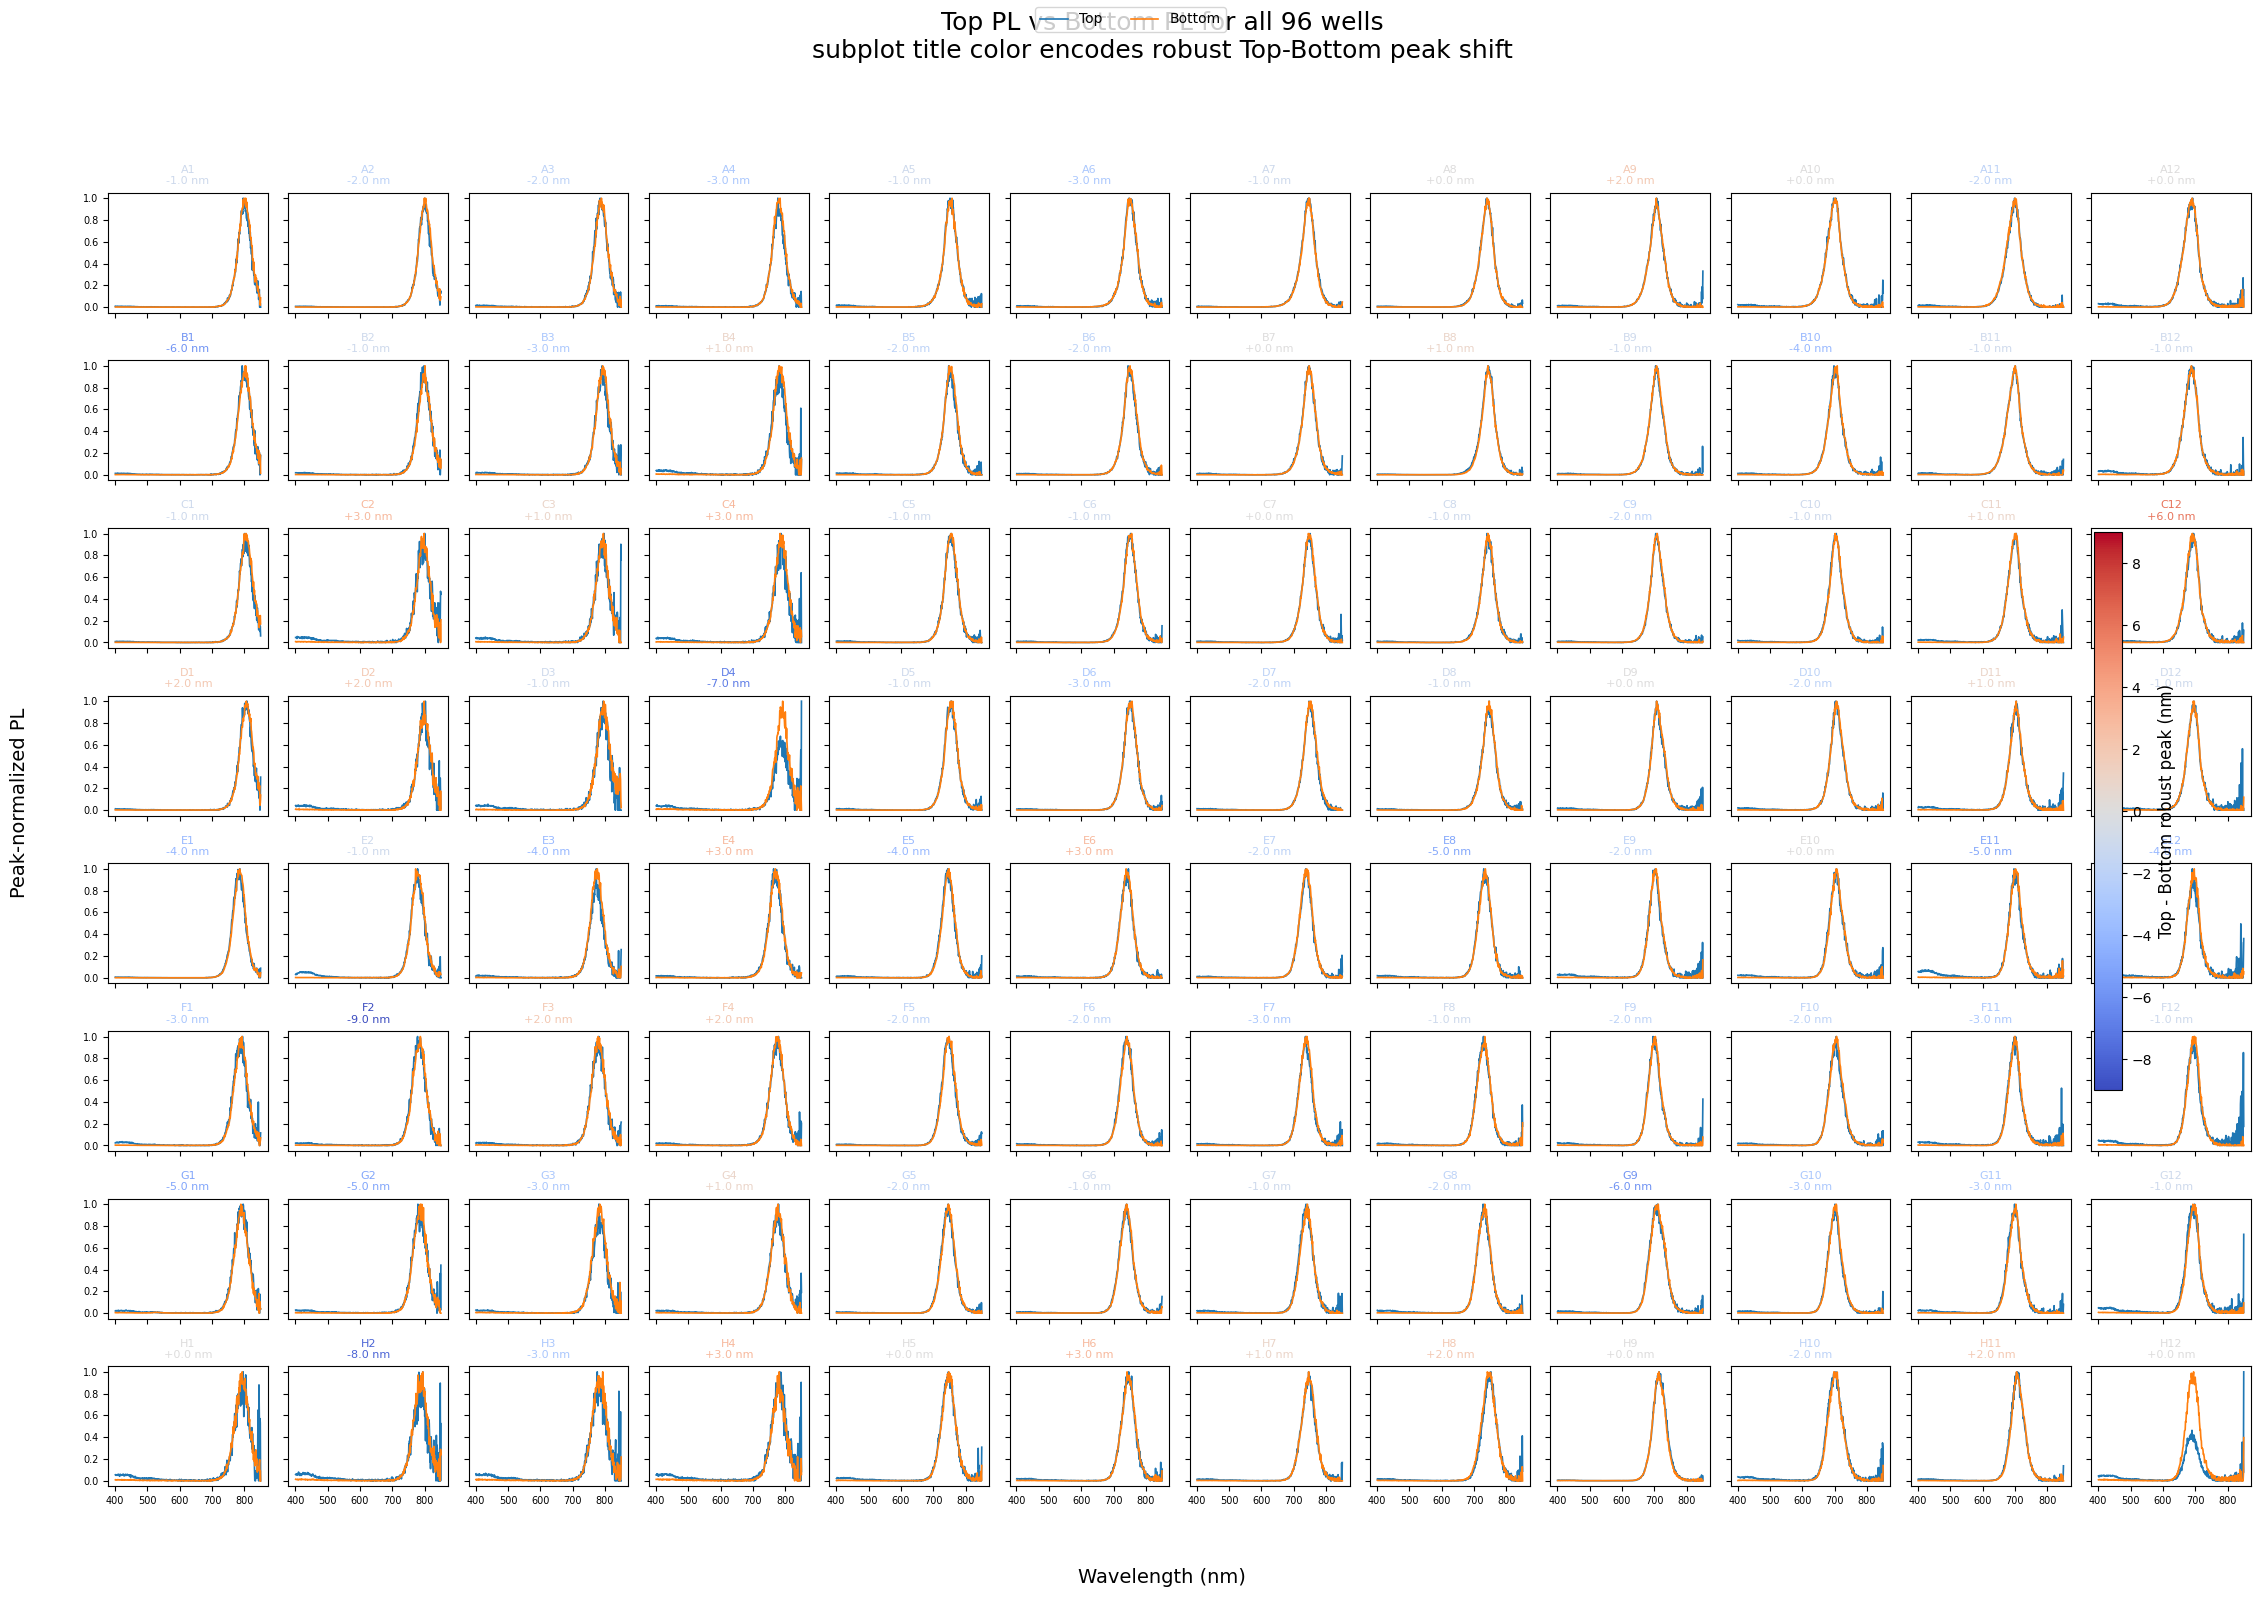

In [17]:
fig = plot_all_top_vs_bottom_pl_colored_titles(
    normalize=True,
)

plt.show()

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import re


def well_sort_key(well):
    """
    Sort wells in plate order:
    A1 ... A12, B1 ... B12, ... H1 ... H12
    """
    match = re.match(r"([A-H])(\d+)", str(well))

    if match is None:
        return (999, 999)

    row_letter = match.group(1)
    column_number = int(match.group(2))

    return (
        ord(row_letter) - ord("A"),
        column_number,
    )


def preprocess_pl_signal(signal, baseline_percentile=5):
    """
    Baseline-correct and peak-normalize a PL signal.
    """
    signal = np.asarray(signal, dtype=float)

    corrected = np.clip(
        signal - np.nanpercentile(signal, baseline_percentile),
        0,
        None,
    )

    maximum = np.nanmax(corrected)

    if np.isfinite(maximum) and maximum > 0:
        corrected = corrected / maximum

    return corrected


def plot_top_minus_bottom_stacked(
    offset_step=1.2,
    figsize=(12, 18),
    baseline_percentile=5,
    linewidth=1.2,
    color="black",
    annotate_wells=True,
):
    """
    Plot (Top PL - Bottom PL) for all wells on the same wavelength axis,
    with vertical offsets so traces do not overlap.

    Parameters
    ----------
    offset_step : float
        Vertical spacing between adjacent wells.

    figsize : tuple
        Figure size.

    baseline_percentile : float
        Percentile used for baseline subtraction before normalization.

    linewidth : float
        Line width for each difference profile.

    color : str
        Line color.

    annotate_wells : bool
        If True, label each trace with its well name.
    """

    wells = sorted(
        quaternary_composition["well"].unique(),
        key=well_sort_key,
    )

    fig, ax = plt.subplots(figsize=figsize)

    ytick_positions = []
    ytick_labels = []

    for i, well in enumerate(wells):

        sample = quaternary_optical[
            quaternary_optical["well"].eq(well)
        ]

        top_rows = (
            sample[
                sample["geometry"].eq("Top")
            ]
            .sort_values("wavelength_nm")
        )

        bottom_rows = (
            sample[
                sample["geometry"].eq("Bottom")
            ]
            .sort_values("wavelength_nm")
        )

        wavelength_top = top_rows[
            "wavelength_nm"
        ].to_numpy(float)

        wavelength_bottom = bottom_rows[
            "wavelength_nm"
        ].to_numpy(float)

        top_signal = top_rows[
            "optical_signal_instrument_units"
        ].to_numpy(float)

        bottom_signal = bottom_rows[
            "optical_signal_instrument_units"
        ].to_numpy(float)

        # Use shared wavelength axis if they already match
        if not np.allclose(wavelength_top, wavelength_bottom):
            raise ValueError(
                f"Wavelength mismatch between Top and Bottom for well {well}"
            )

        wavelength = wavelength_top

        top_processed = preprocess_pl_signal(
            top_signal,
            baseline_percentile=baseline_percentile,
        )

        bottom_processed = preprocess_pl_signal(
            bottom_signal,
            baseline_percentile=baseline_percentile,
        )

        difference = top_processed - bottom_processed

        offset = i * offset_step
        difference_offset = difference + offset

        ax.plot(
            wavelength,
            difference_offset,
            color=color,
            linewidth=linewidth,
        )

        # Zero line for this well's offset
        ax.hlines(
            y=offset,
            xmin=wavelength.min(),
            xmax=wavelength.max(),
            color="lightgray",
            linewidth=0.6,
            linestyles="dashed",
        )

        if annotate_wells:
            ax.text(
                wavelength.min() - 8,
                offset,
                well,
                ha="right",
                va="center",
                fontsize=8,
            )

        ytick_positions.append(offset)
        ytick_labels.append(well)

    ax.set_xlabel("Wavelength (nm)", fontsize=13)
    ax.set_ylabel("Well (stacked offsets)", fontsize=13)

    ax.set_title(
        "Top PL - Bottom PL for all wells\n"
        "Each trace is vertically offset; dashed line = zero difference for that well",
        fontsize=15,
    )

    # Optional: hide y tick labels if well annotations are already shown
    ax.set_yticks(ytick_positions[::4])
    ax.set_yticklabels(ytick_labels[::4], fontsize=8)

    ax.grid(False)

    plt.tight_layout()

    return fig

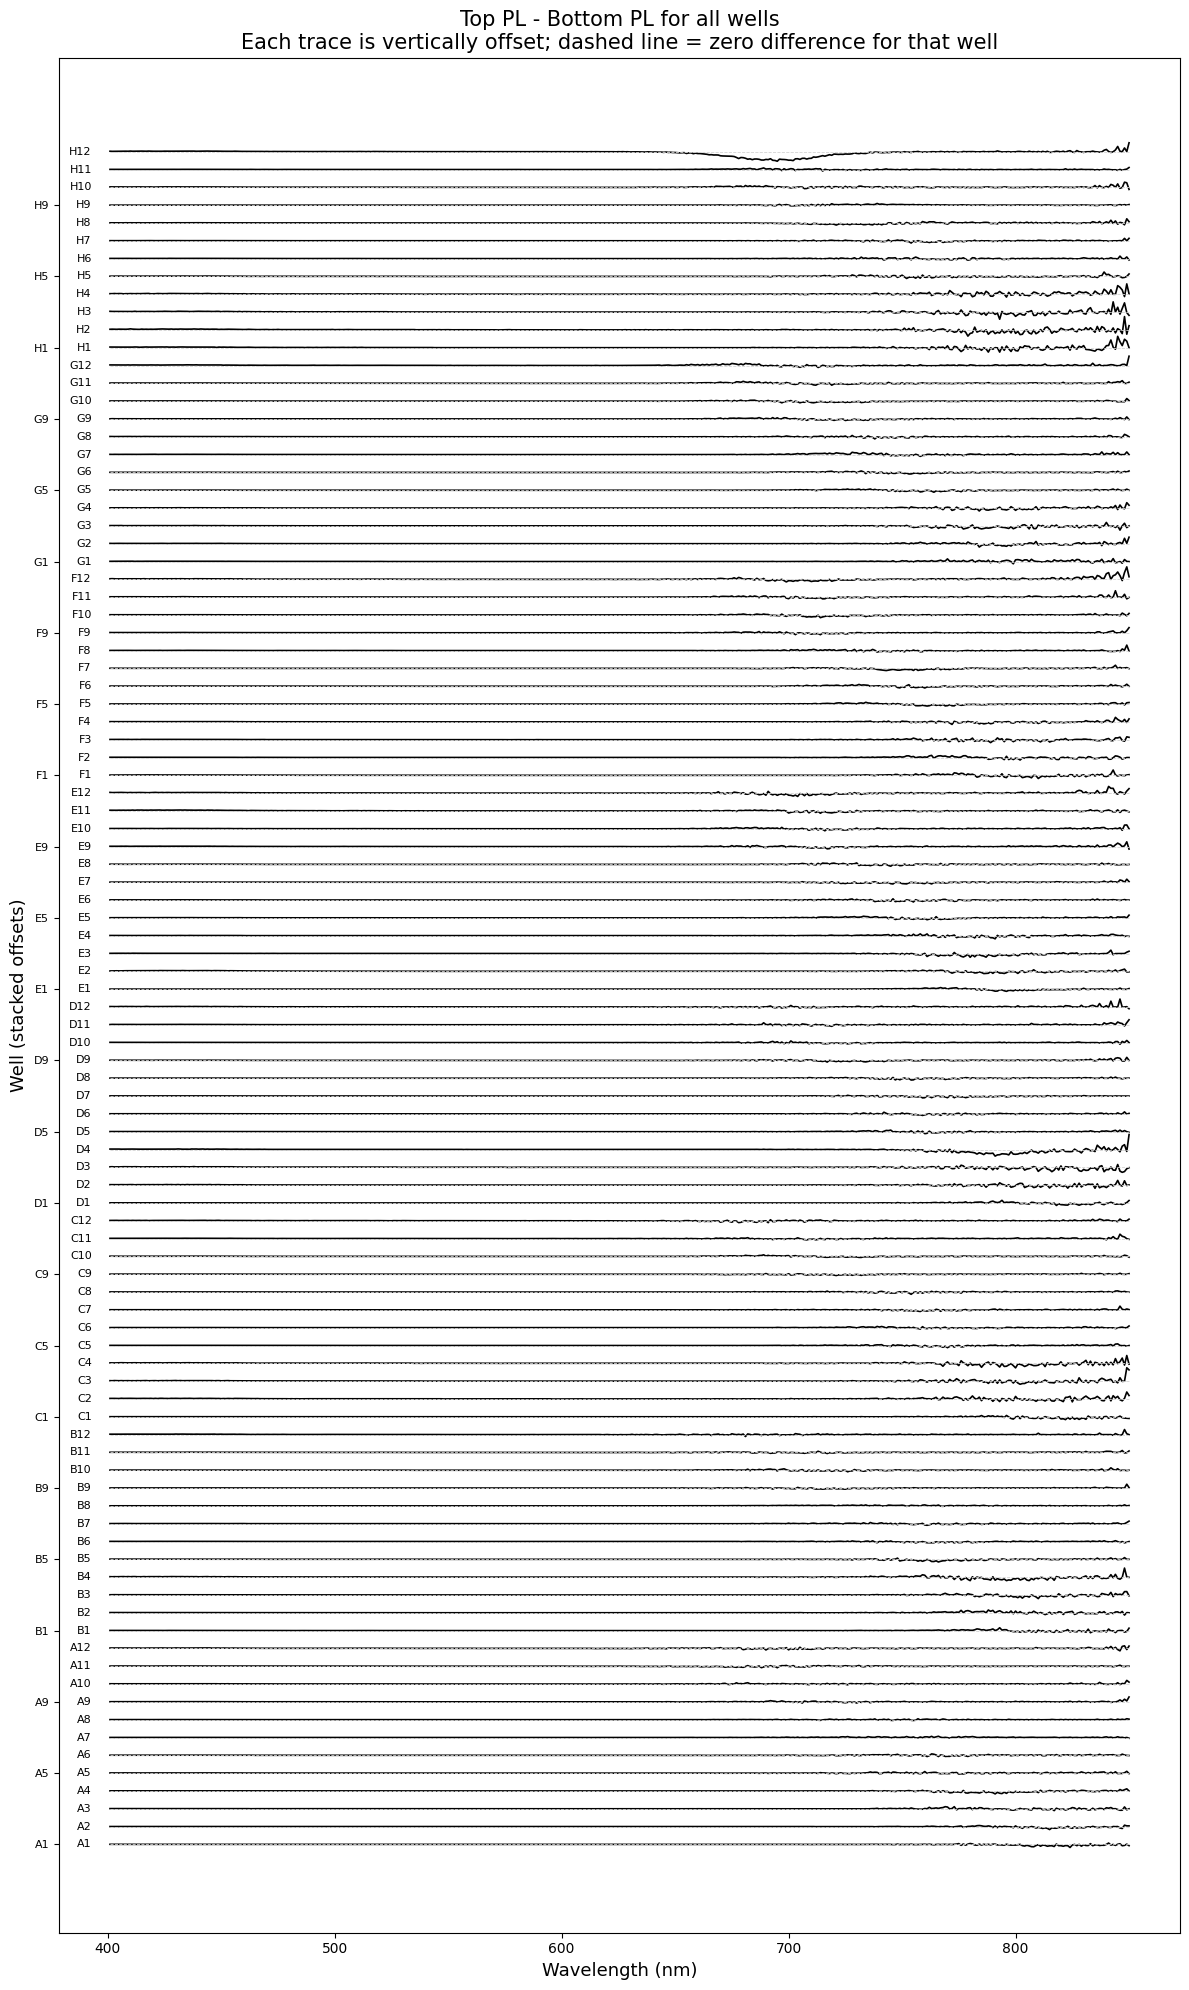

In [19]:
fig = plot_top_minus_bottom_stacked(
    offset_step=1.2,
    figsize=(12, 20),
)

plt.show()

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import re


def well_sort_key(well):
    """
    Sort wells in plate order:
    A1 ... A12, B1 ... B12, ... H1 ... H12
    """
    match = re.match(r"([A-H])(\d+)", str(well))

    if match is None:
        return (999, 999)

    row_letter = match.group(1)
    column_number = int(match.group(2))

    return (
        ord(row_letter) - ord("A"),
        column_number,
    )


def preprocess_pl_signal(signal, baseline_percentile=5):
    """
    Baseline-correct and peak-normalize a PL signal.
    """
    signal = np.asarray(signal, dtype=float)

    corrected = np.clip(
        signal - np.nanpercentile(signal, baseline_percentile),
        0,
        None,
    )

    maximum = np.nanmax(corrected)

    if np.isfinite(maximum) and maximum > 0:
        corrected = corrected / maximum

    return corrected


def plot_top_minus_bottom_stacked_colored(
    offset_step=1.2,
    figsize=(12, 20),
    baseline_percentile=5,
    linewidth=1.4,
    annotate_wells=True,
    metric_col="Top_minus_Bottom_robust_peak_nm",
    cmap_name="coolwarm",
):
    """
    Plot (Top PL - Bottom PL) for all wells on the same wavelength axis,
    with vertical offsets and color-coded traces.

    Trace color encodes the robust Top-Bottom peak shift.

    Parameters
    ----------
    offset_step : float
        Vertical spacing between traces.

    figsize : tuple
        Figure size.

    baseline_percentile : float
        Percentile used for baseline subtraction before normalization.

    linewidth : float
        Line width.

    annotate_wells : bool
        If True, annotate each trace with the well label.

    metric_col : str
        Column in quaternary_features used for trace color.

    cmap_name : str
        Matplotlib colormap name for trace coloring.
    """

    wells = sorted(
        quaternary_composition["well"].unique(),
        key=well_sort_key,
    )

    fig, ax = plt.subplots(figsize=figsize)

    # --------------------------------------------------------
    # Colormap normalization
    # --------------------------------------------------------

    metric_values = quaternary_features[
        metric_col
    ].to_numpy(float)

    max_abs = np.nanmax(
        np.abs(metric_values)
    )

    norm = mcolors.TwoSlopeNorm(
        vmin=-max_abs,
        vcenter=0,
        vmax=max_abs,
    )

    cmap = cm.get_cmap(cmap_name)

    ytick_positions = []
    ytick_labels = []

    for i, well in enumerate(wells):

        sample = quaternary_optical[
            quaternary_optical["well"].eq(well)
        ]

        top_rows = (
            sample[
                sample["geometry"].eq("Top")
            ]
            .sort_values("wavelength_nm")
        )

        bottom_rows = (
            sample[
                sample["geometry"].eq("Bottom")
            ]
            .sort_values("wavelength_nm")
        )

        wavelength_top = top_rows[
            "wavelength_nm"
        ].to_numpy(float)

        wavelength_bottom = bottom_rows[
            "wavelength_nm"
        ].to_numpy(float)

        top_signal = top_rows[
            "optical_signal_instrument_units"
        ].to_numpy(float)

        bottom_signal = bottom_rows[
            "optical_signal_instrument_units"
        ].to_numpy(float)

        if not np.allclose(wavelength_top, wavelength_bottom):
            raise ValueError(
                f"Wavelength mismatch between Top and Bottom for well {well}"
            )

        wavelength = wavelength_top

        top_processed = preprocess_pl_signal(
            top_signal,
            baseline_percentile=baseline_percentile,
        )

        bottom_processed = preprocess_pl_signal(
            bottom_signal,
            baseline_percentile=baseline_percentile,
        )

        difference = top_processed - bottom_processed

        metric_value = quaternary_features.loc[
            quaternary_features["well"].eq(well),
            metric_col,
        ].iloc[0]

        trace_color = cmap(
            norm(metric_value)
        )

        offset = i * offset_step
        difference_offset = difference + offset

        ax.plot(
            wavelength,
            difference_offset,
            color=trace_color,
            linewidth=linewidth,
        )

        # zero line for this well
        ax.hlines(
            y=offset,
            xmin=wavelength.min(),
            xmax=wavelength.max(),
            color="lightgray",
            linewidth=0.6,
            linestyles="dashed",
        )

        if annotate_wells:
            ax.text(
                wavelength.min() - 8,
                offset,
                f"{well}  ({metric_value:+.1f} nm)",
                ha="right",
                va="center",
                fontsize=8,
                color=trace_color,
            )

        ytick_positions.append(offset)
        ytick_labels.append(well)

    ax.set_xlabel(
        "Wavelength (nm)",
        fontsize=13,
    )

    ax.set_ylabel(
        "Well (stacked offsets)",
        fontsize=13,
    )

    ax.set_title(
        "Top PL - Bottom PL for all wells\n"
        "Trace color encodes robust Top-Bottom peak shift",
        fontsize=15,
    )

    # Show only some y ticks to reduce clutter
    ax.set_yticks(ytick_positions[::4])
    ax.set_yticklabels(ytick_labels[::4], fontsize=8)

    ax.grid(False)

    # --------------------------------------------------------
    # Colorbar
    # --------------------------------------------------------

    sm = cm.ScalarMappable(
        norm=norm,
        cmap=cmap,
    )
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        orientation="vertical",
        pad=0.02,
    )

    cbar.set_label(
        "Top - Bottom robust peak (nm)",
        fontsize=12,
    )

    plt.tight_layout()

    return fig

/var/folders/_g/8z89zb491m5gsltgwq_5wvkm0000gn/T/ipykernel_45290/2079324545.py:111: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


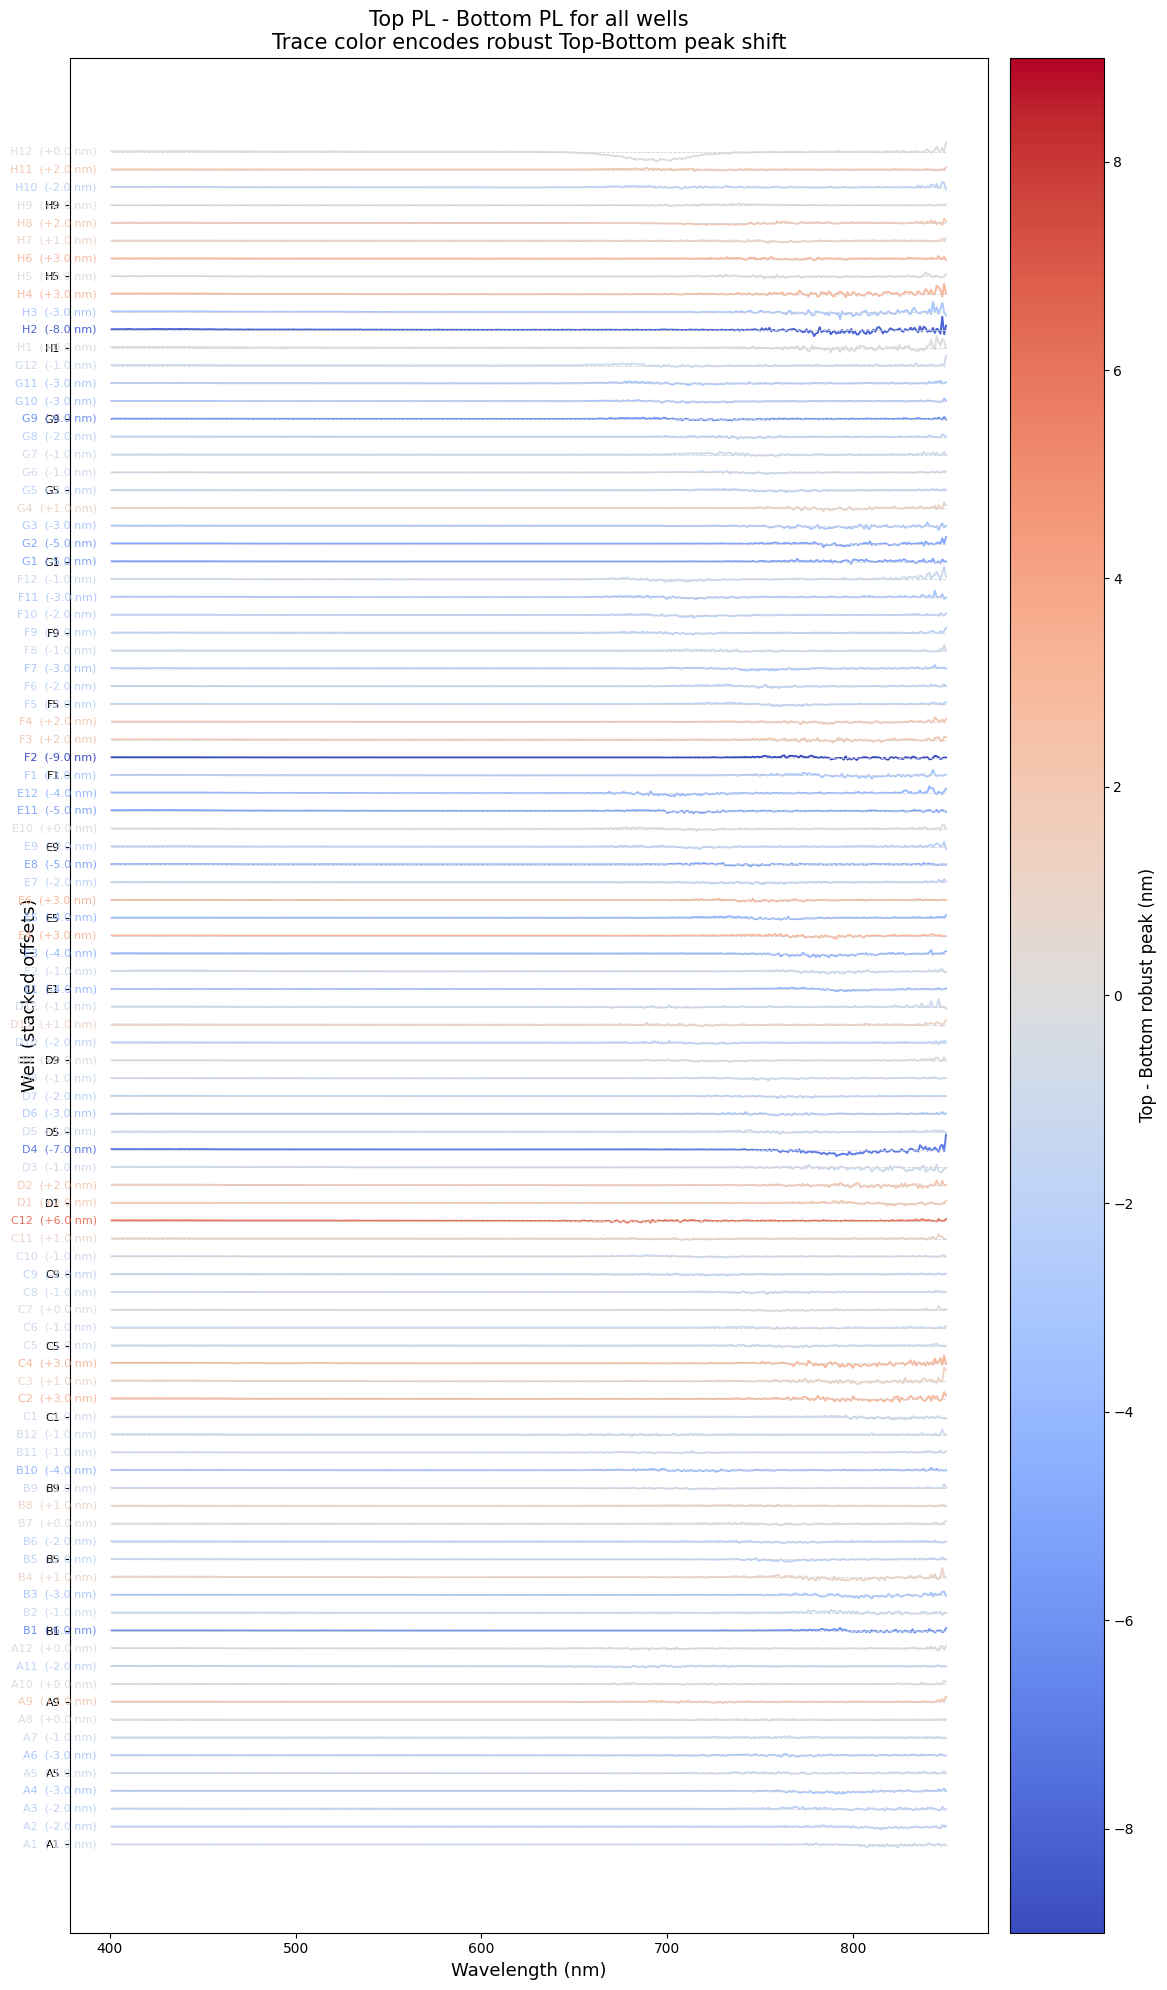

In [21]:
fig = plot_top_minus_bottom_stacked_colored(
    offset_step=1.2,
    figsize=(12, 20),
)

plt.show()

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import re


def well_sort_key(well):
    """
    Sort wells in plate order:
    A1 ... A12, B1 ... B12, ... H1 ... H12
    """
    match = re.match(r"([A-H])(\d+)", str(well))

    if match is None:
        return (999, 999)

    row_letter = match.group(1)
    column_number = int(match.group(2))

    return (
        ord(row_letter) - ord("A"),
        column_number,
    )


def preprocess_pl_signal(signal, baseline_percentile=5):
    """
    Baseline-correct and peak-normalize a PL signal.
    """
    signal = np.asarray(signal, dtype=float)

    corrected = np.clip(
        signal - np.nanpercentile(signal, baseline_percentile),
        0,
        None,
    )

    maximum = np.nanmax(corrected)

    if np.isfinite(maximum) and maximum > 0:
        corrected = corrected / maximum

    return corrected


def make_no_white_diverging_cmap():
    """
    Custom diverging colormap with a visible gray midpoint
    instead of white.
    """

    colors = [
        "#2166ac",   # deep blue
        "#67a9cf",   # light blue
        "#bdbdbd",   # gray midpoint
        "#ef8a62",   # orange-red
        "#b2182b",   # deep red
    ]

    return mcolors.LinearSegmentedColormap.from_list(
        "no_white_diverging",
        colors,
        N=256,
    )


def plot_top_minus_bottom_stacked_colored_nowhite(
    offset_step=1.2,
    figsize=(12, 20),
    baseline_percentile=5,
    linewidth=1.4,
    annotate_wells=True,
    metric_col="Top_minus_Bottom_robust_peak_nm",
):
    """
    Plot (Top PL - Bottom PL) for all wells on the same wavelength axis,
    vertically offset, with trace color encoding the robust Top-Bottom peak shift.

    Uses a no-white diverging colormap:
        blue  -> negative shift
        gray  -> near zero
        red   -> positive shift
    """

    wells = sorted(
        quaternary_composition["well"].unique(),
        key=well_sort_key,
    )

    fig, ax = plt.subplots(figsize=figsize)

    # --------------------------------------------------------
    # Colormap normalization
    # --------------------------------------------------------

    metric_values = quaternary_features[
        metric_col
    ].to_numpy(float)

    max_abs = np.nanmax(
        np.abs(metric_values)
    )

    norm = mcolors.TwoSlopeNorm(
        vmin=-max_abs,
        vcenter=0,
        vmax=max_abs,
    )

    cmap = make_no_white_diverging_cmap()

    ytick_positions = []
    ytick_labels = []

    for i, well in enumerate(wells):

        sample = quaternary_optical[
            quaternary_optical["well"].eq(well)
        ]

        top_rows = (
            sample[
                sample["geometry"].eq("Top")
            ]
            .sort_values("wavelength_nm")
        )

        bottom_rows = (
            sample[
                sample["geometry"].eq("Bottom")
            ]
            .sort_values("wavelength_nm")
        )

        wavelength_top = top_rows[
            "wavelength_nm"
        ].to_numpy(float)

        wavelength_bottom = bottom_rows[
            "wavelength_nm"
        ].to_numpy(float)

        top_signal = top_rows[
            "optical_signal_instrument_units"
        ].to_numpy(float)

        bottom_signal = bottom_rows[
            "optical_signal_instrument_units"
        ].to_numpy(float)

        if not np.allclose(wavelength_top, wavelength_bottom):
            raise ValueError(
                f"Wavelength mismatch between Top and Bottom for well {well}"
            )

        wavelength = wavelength_top

        top_processed = preprocess_pl_signal(
            top_signal,
            baseline_percentile=baseline_percentile,
        )

        bottom_processed = preprocess_pl_signal(
            bottom_signal,
            baseline_percentile=baseline_percentile,
        )

        difference = top_processed - bottom_processed

        metric_value = quaternary_features.loc[
            quaternary_features["well"].eq(well),
            metric_col,
        ].iloc[0]

        trace_color = cmap(
            norm(metric_value)
        )

        offset = i * offset_step
        difference_offset = difference + offset

        # Main difference trace
        ax.plot(
            wavelength,
            difference_offset,
            color=trace_color,
            linewidth=linewidth,
        )

        # Zero-difference baseline for this well
        ax.hlines(
            y=offset,
            xmin=wavelength.min(),
            xmax=wavelength.max(),
            color="lightgray",
            linewidth=0.6,
            linestyles="dashed",
        )

        if annotate_wells:
            ax.text(
                wavelength.min() - 8,
                offset,
                f"{well}  ({metric_value:+.1f} nm)",
                ha="right",
                va="center",
                fontsize=8,
                color=trace_color,
            )

        ytick_positions.append(offset)
        ytick_labels.append(well)

    ax.set_xlabel(
        "Wavelength (nm)",
        fontsize=13,
    )

    ax.set_ylabel(
        "Well (stacked offsets)",
        fontsize=13,
    )

    ax.set_title(
        "Top PL - Bottom PL for all wells\n"
        "Trace color encodes robust Top-Bottom peak shift",
        fontsize=15,
    )

    # Show only every 4th tick to reduce clutter
    ax.set_yticks(ytick_positions[::4])
    ax.set_yticklabels(
        ytick_labels[::4],
        fontsize=8,
    )

    ax.grid(False)

    # --------------------------------------------------------
    # Colorbar
    # --------------------------------------------------------

    sm = plt.cm.ScalarMappable(
        norm=norm,
        cmap=cmap,
    )
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        orientation="vertical",
        pad=0.02,
    )

    cbar.set_label(
        "Top - Bottom robust peak (nm)",
        fontsize=12,
    )

    plt.tight_layout()

    return fig

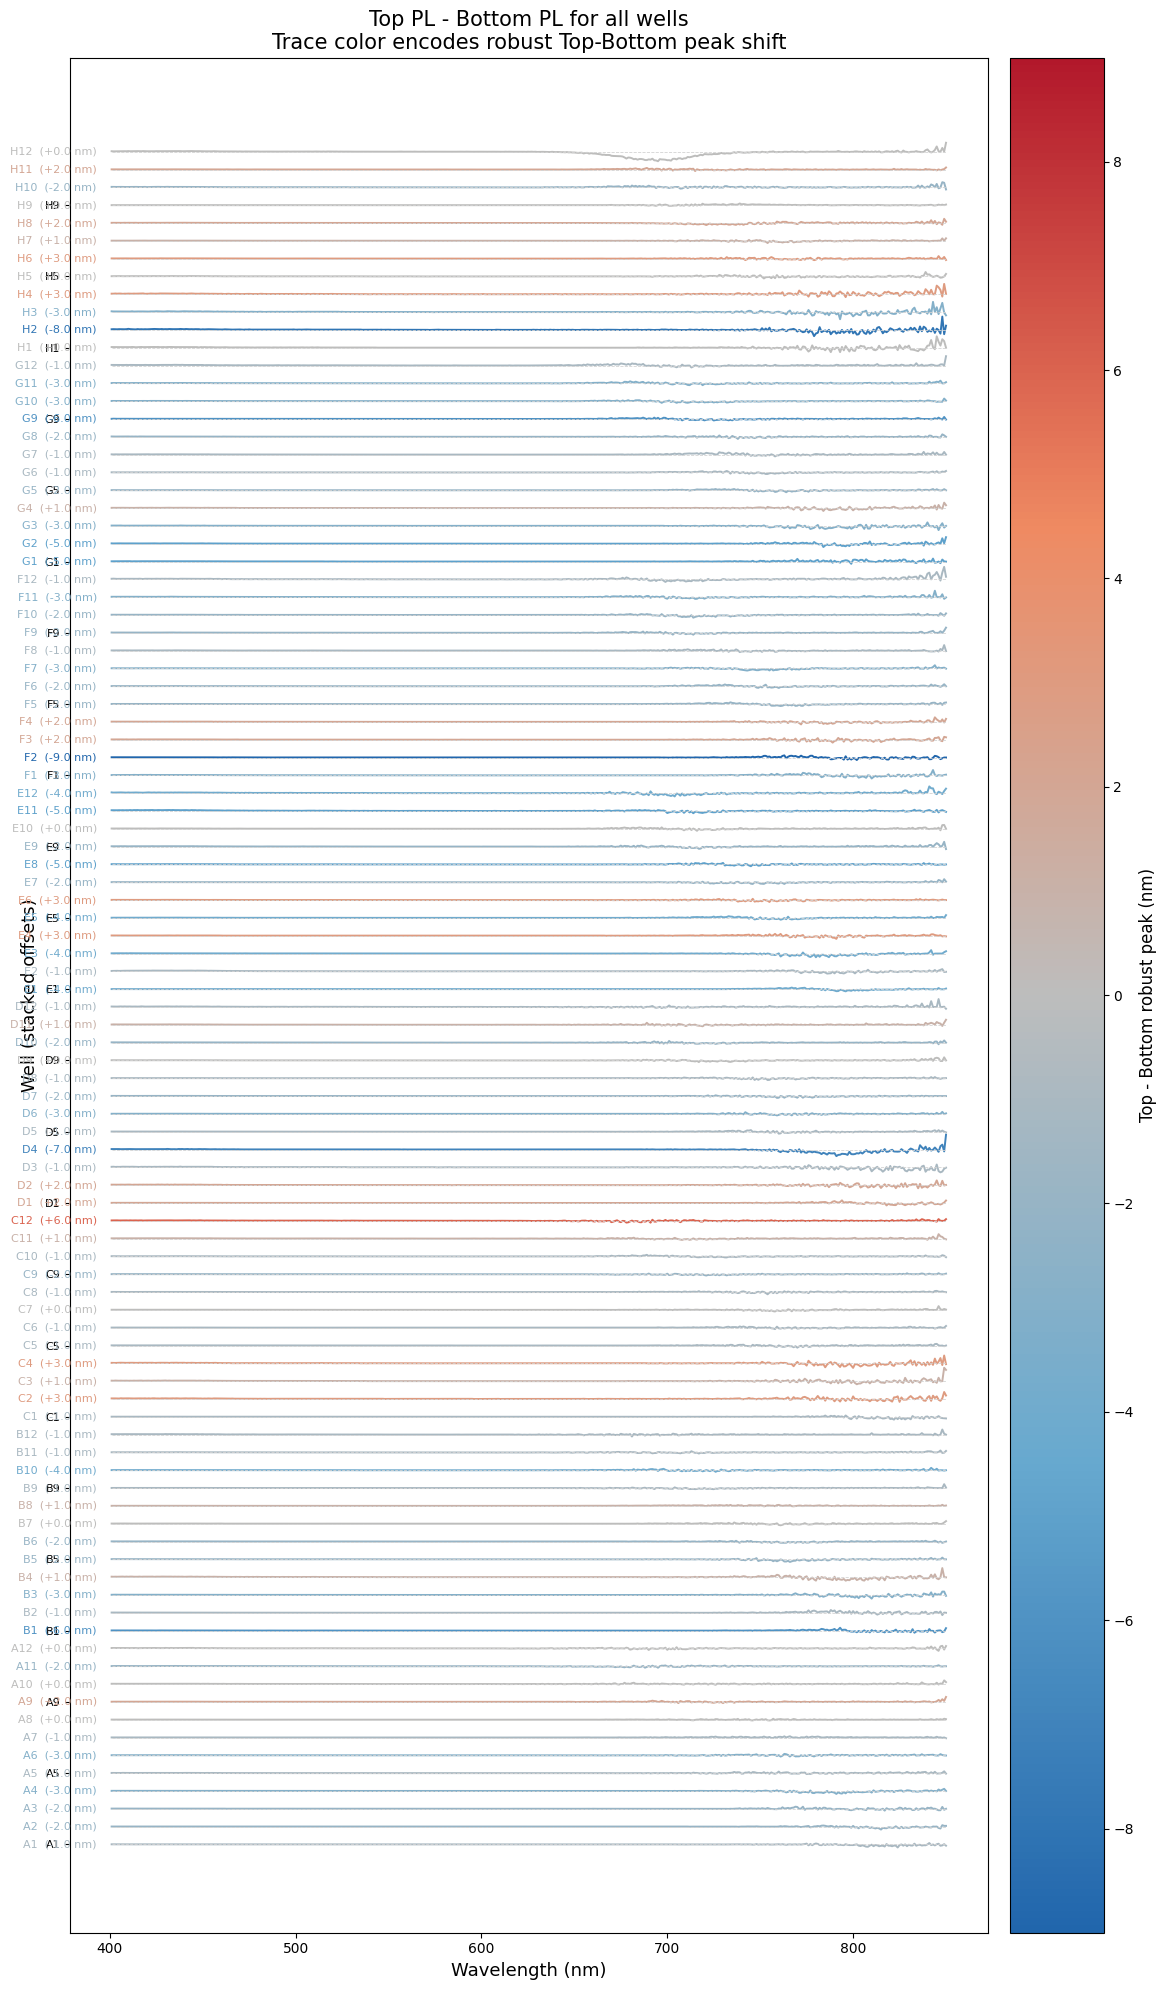

In [23]:
fig = plot_top_minus_bottom_stacked_colored_nowhite(
    offset_step=1.2,
    figsize=(12, 20),
)

plt.show()

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import re


def well_sort_key(well):
    """
    Sort wells in plate order:
    A1 ... A12, B1 ... B12, ... H1 ... H12
    """
    match = re.match(r"([A-H])(\d+)", str(well))

    if match is None:
        return (999, 999)

    row_letter = match.group(1)
    column_number = int(match.group(2))

    return (
        ord(row_letter) - ord("A"),
        column_number,
    )


def make_no_white_diverging_cmap():
    """
    Custom diverging colormap with gray midpoint instead of white.
    """
    colors = [
        "#2166ac",   # deep blue
        "#67a9cf",   # light blue
        "#bdbdbd",   # gray midpoint
        "#ef8a62",   # orange-red
        "#b2182b",   # deep red
    ]

    return mcolors.LinearSegmentedColormap.from_list(
        "no_white_diverging",
        colors,
        N=256,
    )


def plot_peak_position_difference_by_well(
    metric_col="Top_minus_Bottom_robust_peak_nm",
    figsize=(16, 5),
    annotate=False,
):
    """
    Plot Top peak - Bottom peak (in nm) for each well.

    Parameters
    ----------
    metric_col : str
        Column in quaternary_features containing the robust
        peak-position difference.

    figsize : tuple
        Figure size.

    annotate : bool
        If True, annotate each point/bar with the numeric value.
    """

    # --------------------------------------------------------
    # Sort wells in plate order
    # --------------------------------------------------------

    df = quaternary_features.copy()

    df["well_sort"] = df["well"].map(well_sort_key)

    df = df.sort_values("well_sort").reset_index(drop=True)

    wells = df["well"].tolist()
    values = df[metric_col].to_numpy(float)

    x = np.arange(len(wells))

    # --------------------------------------------------------
    # No-white diverging colormap
    # --------------------------------------------------------

    max_abs = np.nanmax(np.abs(values))

    norm = mcolors.TwoSlopeNorm(
        vmin=-max_abs,
        vcenter=0,
        vmax=max_abs,
    )

    cmap = make_no_white_diverging_cmap()
    colors = [cmap(norm(v)) for v in values]

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=figsize)

    bars = ax.bar(
        x,
        values,
        color=colors,
        edgecolor="black",
        linewidth=0.6,
    )

    ax.axhline(
        0,
        color="black",
        linewidth=1.0,
        linestyle="--",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        wells,
        rotation=90,
        fontsize=8,
    )

    ax.set_ylabel(
        "Top peak - Bottom peak (nm)",
        fontsize=12,
    )

    ax.set_xlabel(
        "Well",
        fontsize=12,
    )

    ax.set_title(
        "Peak position difference between Top PL and Bottom PL for each well",
        fontsize=14,
    )

    # --------------------------------------------------------
    # Optional annotations
    # --------------------------------------------------------

    if annotate:
        for xi, yi in zip(x, values):
            va = "bottom" if yi >= 0 else "top"
            y_text = yi + 0.15 if yi >= 0 else yi - 0.15

            ax.text(
                xi,
                y_text,
                f"{yi:+.1f}",
                ha="center",
                va=va,
                fontsize=6,
            )

    # --------------------------------------------------------
    # Colorbar
    # --------------------------------------------------------

    sm = plt.cm.ScalarMappable(
        norm=norm,
        cmap=cmap,
    )
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        pad=0.01,
    )

    cbar.set_label(
        "Top - Bottom robust peak (nm)",
        fontsize=11,
    )

    plt.tight_layout()

    return fig

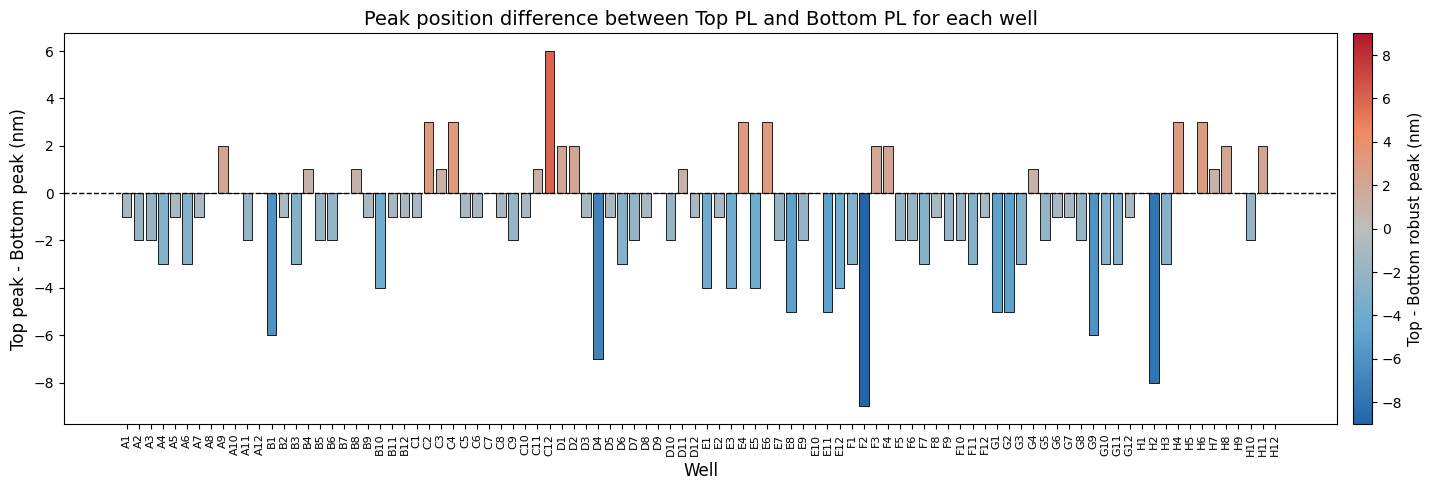

In [25]:
fig = plot_peak_position_difference_by_well(
    annotate=False
)

plt.show()

In [26]:
def plot_peak_position_difference_by_well_scatter(
    metric_col="Top_minus_Bottom_robust_peak_nm",
    figsize=(16, 5),
    annotate=False,
):
    df = quaternary_features.copy()
    df["well_sort"] = df["well"].map(well_sort_key)
    df = df.sort_values("well_sort").reset_index(drop=True)

    wells = df["well"].tolist()
    values = df[metric_col].to_numpy(float)

    x = np.arange(len(wells))

    max_abs = np.nanmax(np.abs(values))

    norm = mcolors.TwoSlopeNorm(
        vmin=-max_abs,
        vcenter=0,
        vmax=max_abs,
    )

    cmap = make_no_white_diverging_cmap()
    colors = [cmap(norm(v)) for v in values]

    fig, ax = plt.subplots(figsize=figsize)

    ax.axhline(
        0,
        color="black",
        linewidth=1.0,
        linestyle="--",
    )

    ax.scatter(
        x,
        values,
        c=colors,
        s=55,
        edgecolors="black",
        linewidths=0.5,
        zorder=3,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        wells,
        rotation=90,
        fontsize=8,
    )

    ax.set_ylabel(
        "Top peak - Bottom peak (nm)",
        fontsize=12,
    )

    ax.set_xlabel(
        "Well",
        fontsize=12,
    )

    ax.set_title(
        "Peak position difference between Top PL and Bottom PL for each well",
        fontsize=14,
    )

    if annotate:
        for xi, yi in zip(x, values):
            va = "bottom" if yi >= 0 else "top"
            y_text = yi + 0.15 if yi >= 0 else yi - 0.15

            ax.text(
                xi,
                y_text,
                f"{yi:+.1f}",
                ha="center",
                va=va,
                fontsize=6,
            )

    sm = plt.cm.ScalarMappable(
        norm=norm,
        cmap=cmap,
    )
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        pad=0.01,
    )

    cbar.set_label(
        "Top - Bottom robust peak (nm)",
        fontsize=11,
    )

    plt.tight_layout()

    return fig

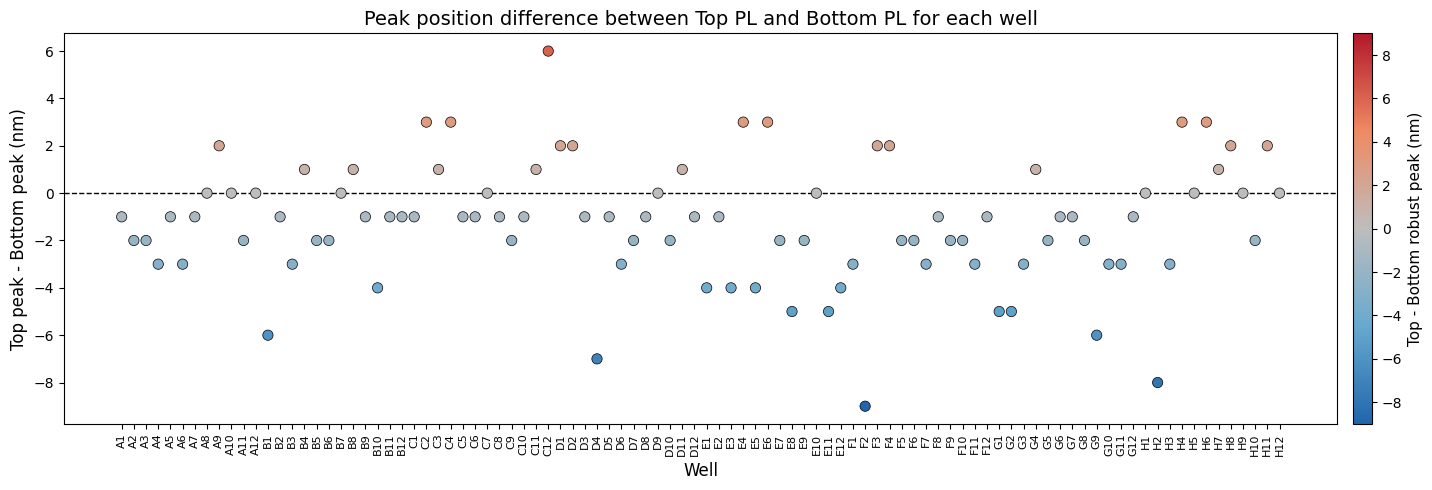

In [27]:
fig = plot_peak_position_difference_by_well_scatter()
plt.show()

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import re


def make_no_white_diverging_cmap():
    """
    Custom diverging colormap with a gray midpoint instead of white.
    """
    colors = [
        "#2166ac",   # deep blue
        "#67a9cf",   # light blue
        "#bdbdbd",   # gray midpoint
        "#ef8a62",   # orange-red
        "#b2182b",   # deep red
    ]

    return mcolors.LinearSegmentedColormap.from_list(
        "no_white_diverging",
        colors,
        N=256,
    )


def parse_well(well):
    """
    Convert a well like 'F2' into:
        row letter = 'F'
        row index  = 5
        column     = 2
        col index  = 1
    """
    match = re.match(r"([A-H])(\d+)", str(well))

    if match is None:
        raise ValueError(f"Could not parse well: {well}")

    row_letter = match.group(1)
    column_number = int(match.group(2))

    row_index = ord(row_letter) - ord("A")
    col_index = column_number - 1

    return row_letter, row_index, column_number, col_index


def plot_peak_difference_plate_heatmap(
    metric_col="Top_minus_Bottom_robust_peak_nm",
    annotate=True,
    figsize=(12, 6),
):
    """
    Plate-layout heatmap of robust Top-Bottom peak wavelength difference.

    Parameters
    ----------
    metric_col : str
        Column in quaternary_features containing the robust peak shift.

    annotate : bool
        If True, write the numeric value inside each well.

    figsize : tuple
        Figure size.
    """

    # Plate dimensions
    row_labels = list("ABCDEFGH")
    col_labels = list(range(1, 13))

    data = np.full((8, 12), np.nan)

    # Fill heatmap matrix
    for _, row in quaternary_features.iterrows():

        well = row["well"]
        value = row[metric_col]

        row_letter, row_index, column_number, col_index = parse_well(well)

        data[row_index, col_index] = value

    # Symmetric color range around zero
    max_abs = np.nanmax(np.abs(data))

    norm = mcolors.TwoSlopeNorm(
        vmin=-max_abs,
        vcenter=0,
        vmax=max_abs,
    )

    cmap = make_no_white_diverging_cmap()

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        data,
        cmap=cmap,
        norm=norm,
        aspect="auto",
        origin="upper",
    )

    # Axis labels
    ax.set_xticks(np.arange(12))
    ax.set_xticklabels(col_labels, fontsize=11)

    ax.set_yticks(np.arange(8))
    ax.set_yticklabels(row_labels, fontsize=11)

    ax.set_xlabel("Column", fontsize=13)
    ax.set_ylabel("Row", fontsize=13)

    ax.set_title(
        "Plate-layout heatmap of Top PL - Bottom PL robust peak difference",
        fontsize=15,
    )

    # Draw grid lines between wells
    ax.set_xticks(np.arange(-0.5, 12, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 8, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=0.8)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Optional annotations
    if annotate:
        for i in range(8):
            for j in range(12):

                value = data[i, j]

                if np.isfinite(value):

                    ax.text(
                        j,
                        i,
                        f"{value:+.1f}",
                        ha="center",
                        va="center",
                        fontsize=9,
                        color="black",
                    )

    # Colorbar
    cbar = fig.colorbar(
        im,
        ax=ax,
        pad=0.02,
    )

    cbar.set_label(
        "Top - Bottom robust peak (nm)",
        fontsize=12,
    )

    plt.tight_layout()

    return fig

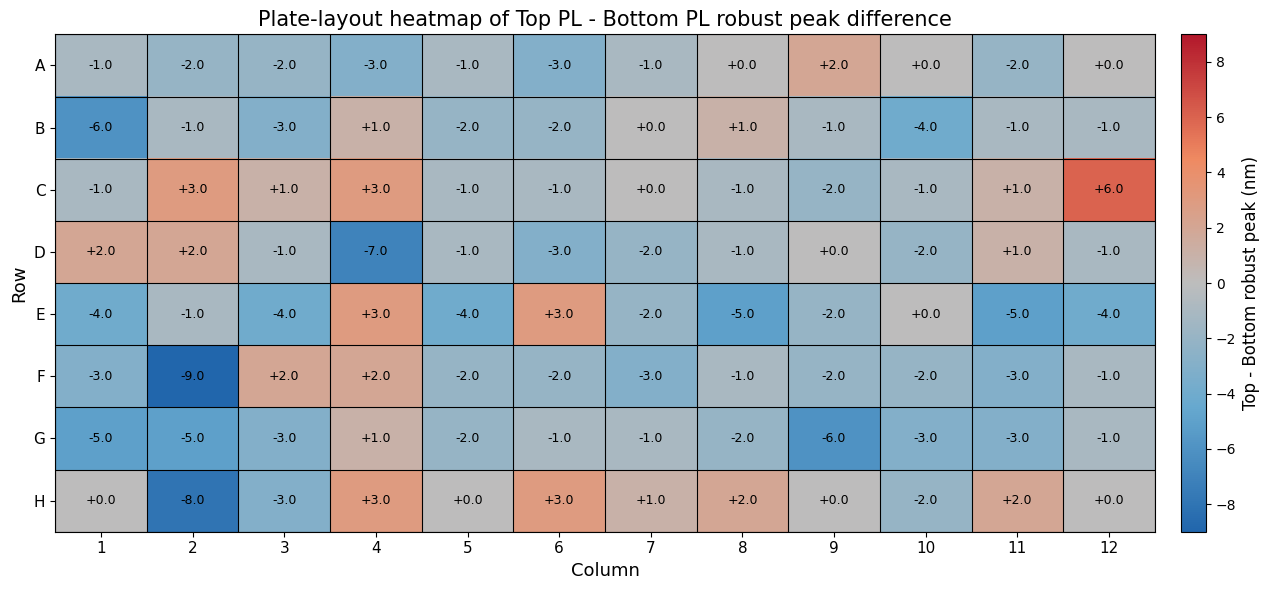

In [29]:
fig = plot_peak_difference_plate_heatmap(
    annotate=True,
    figsize=(14, 6),
)

plt.show()

In [32]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import re


# ============================================================
# HELPER: PARSE WELL LABEL
# ============================================================

def parse_well(well):
    """
    Convert well label like 'F2' into:
        row_letter = 'F'
        row_index  = 5
        col_number = 2
    """

    match = re.match(
        r"([A-H])(\d+)",
        str(well)
    )

    if match is None:
        raise ValueError(
            f"Could not parse well: {well}"
        )

    row_letter = match.group(1)
    col_number = int(match.group(2))

    row_index = (
        ord(row_letter) - ord("A")
    )

    return (
        row_letter,
        row_index,
        col_number,
    )


# ============================================================
# 3D AVERAGE PEAK POSITION PLOT
# ============================================================

def plot_average_peak_position_3d(
    z_padding_fraction=0.05,
    minimum_z_padding=2.0,
    show_well_labels=True,
):
    """
    Plot average robust PL peak position for each well.

    x-axis = plate row letter (A-H)
    y-axis = plate column number (1-12)
    z-axis = average of Top and Bottom robust PL peaks

    Parameters
    ----------
    z_padding_fraction : float
        Fraction of the observed z-range added as padding.

    minimum_z_padding : float
        Minimum padding in nm above and below the data.

    show_well_labels : bool
        If True, display well labels beside the points.
    """

    # --------------------------------------------------------
    # Copy feature table
    # --------------------------------------------------------

    df = quaternary_features.copy()


    # --------------------------------------------------------
    # Check required columns
    # --------------------------------------------------------

    required_columns = [
        "well",
        "Top_robust_peak_nm",
        "Bottom_robust_peak_nm",
    ]

    for column in required_columns:

        if column not in df.columns:

            raise ValueError(
                f"Required column '{column}' "
                "not found in quaternary_features."
            )


    # --------------------------------------------------------
    # Average Top and Bottom robust peak positions
    # --------------------------------------------------------

    df["Average_peak_nm"] = (

        df["Top_robust_peak_nm"]
        +
        df["Bottom_robust_peak_nm"]

    ) / 2.0


    # Remove rows with missing peak data
    df = df.dropna(
        subset=[
            "Average_peak_nm"
        ]
    ).copy()


    # --------------------------------------------------------
    # Parse plate coordinates
    # --------------------------------------------------------

    parsed = df["well"].apply(
        parse_well
    )


    df["row_letter"] = parsed.apply(
        lambda value: value[0]
    )

    df["row_index"] = parsed.apply(
        lambda value: value[1]
    )

    df["col_number"] = parsed.apply(
        lambda value: value[2]
    )


    # Sort in plate order
    df = df.sort_values(
        [
            "row_index",
            "col_number",
        ]
    ).reset_index(drop=True)


    # ========================================================
    # TIGHT Z-AXIS LIMITS
    # ========================================================

    z_min = df[
        "Average_peak_nm"
    ].min()

    z_max = df[
        "Average_peak_nm"
    ].max()

    z_span = z_max - z_min


    z_padding = max(

        z_padding_fraction * z_span,

        minimum_z_padding,
    )


    z_lower = z_min - z_padding
    z_upper = z_max + z_padding


    print(
        f"Average peak range: "
        f"{z_min:.1f} to {z_max:.1f} nm"
    )

    print(
        f"Displayed z-axis range: "
        f"{z_lower:.1f} to {z_upper:.1f} nm"
    )


    # ========================================================
    # BUILD HOVER DATA
    # ========================================================

    hover_columns = [
        "well",
        "Top_robust_peak_nm",
        "Bottom_robust_peak_nm",
        "Average_peak_nm",
    ]


    # Add composition columns if available
    optional_columns = [
        "FA_fraction",
        "Cs_fraction",
        "Rb_fraction",
        "DMA_fraction",
        "I_fraction",
        "Br_fraction",
        "Cl_fraction",
    ]


    for column in optional_columns:

        if column in df.columns:
            hover_columns.append(
                column
            )


    custom_data = df[
        hover_columns
    ].to_numpy()


    # ========================================================
    # 3D SCATTER
    # ========================================================

    fig = go.Figure()


    fig.add_trace(

        go.Scatter3d(

            x=df["row_index"],

            y=df["col_number"],

            z=df["Average_peak_nm"],


            mode=(
                "markers+text"
                if show_well_labels
                else "markers"
            ),


            text=(
                df["well"]
                if show_well_labels
                else None
            ),


            textposition="top center",


            marker=dict(

                size=7,

                color=df[
                    "Average_peak_nm"
                ],

                colorscale="Viridis",

                cmin=z_min,

                cmax=z_max,

                colorbar=dict(
                    title="Average peak<br>(nm)"
                ),

                line=dict(
                    color="black",
                    width=0.5,
                ),
            ),


            customdata=custom_data,


            hovertemplate=(

                "<b>Well %{customdata[0]}</b>"

                "<br>Top peak = "
                "%{customdata[1]:.1f} nm"

                "<br>Bottom peak = "
                "%{customdata[2]:.1f} nm"

                "<br><b>Average peak = "
                "%{customdata[3]:.1f} nm</b>"

                "<extra></extra>"
            ),
        )
    )


    # ========================================================
    # LAYOUT
    # ========================================================

    fig.update_layout(

        title=(
            "Average robust PL peak position "
            "across the 96-well plate"
        ),

        height=800,

        template="plotly_white",


        scene=dict(

            # ------------------------------------------------
            # X AXIS: ROW LETTER
            # ------------------------------------------------

            xaxis=dict(

                title="Plate row",

                tickmode="array",

                tickvals=list(
                    range(8)
                ),

                ticktext=list(
                    "ABCDEFGH"
                ),
            ),


            # ------------------------------------------------
            # Y AXIS: COLUMN NUMBER
            # ------------------------------------------------

            yaxis=dict(

                title="Plate column",

                tickmode="array",

                tickvals=list(
                    range(1, 13)
                ),

                ticktext=[
                    str(value)
                    for value in range(1, 13)
                ],
            ),


            # ------------------------------------------------
            # Z AXIS: TIGHT PEAK RANGE
            # ------------------------------------------------

            zaxis=dict(

                title=(
                    "Average peak position (nm)"
                ),

                range=[
                    z_lower,
                    z_upper,
                ],

                nticks=8,
            ),


            # ------------------------------------------------
            # CAMERA
            # ------------------------------------------------

            camera=dict(

                eye=dict(

                    x=1.5,

                    y=1.6,

                    z=1.1,
                )
            ),


            aspectmode="manual",

            aspectratio=dict(

                x=1.0,

                y=1.3,

                z=0.8,
            ),
        ),


        margin=dict(

            l=10,

            r=10,

            t=60,

            b=10,
        ),
    )


    return fig


# ============================================================
# RUN
# ============================================================

average_peak_3d = (
    plot_average_peak_position_3d()
)

average_peak_3d.show()

Average peak range: 688.5 to 807.0 nm
Displayed z-axis range: 682.6 to 812.9 nm


<h2><font color="purple">3.</font> Explore the RP-Additive System</h2>

### Problem 2

> **Where do emission bands appear, disappear, or shift with composition and time,
> and do Top and Bottom measurements tell the same story?**

Columns vary the nominal 3AMP/FAPbI3 host mix. Rows vary the nominal MACl design
level. Each well has Top and Bottom PL every 20 minutes from 0 to 380 minutes.

The host fractions form one closed basis. MACl is a separate experimental axis. A
single final-time map hides the trajectory, while 20 separate maps are cumbersome.
The baseline solution pairs a **composition overview at one time** with a
**time × wavelength heatmap** for one selected well.


In [ ]:
# Reusable Challenge 2 composition map at one elapsed time
RP_METRICS = {
    "red_fraction_760_820": "Fraction of PL from 760–820 nm",
    "peak_nm": "Dominant emission (nm)",
    "peak_shift_vs_t0": "Peak shift from t0 (nm)",
    "retention_vs_t0": "Integrated PL / t0",
}
RP_COLORBAR_TITLES = {
    "red_fraction_760_820": "760–820 nm<br>PL fraction",
    "peak_nm": "Peak<br>(nm)",
    "peak_shift_vs_t0": "Peak shift<br>(nm)",
    "retention_vs_t0": "PL / t0",
}

def rp_composition_map(
    measure="Bottom PL", time_min=380, metric="red_fraction_760_820",
    selected_well="H7",
):
    current = rp_features[
        rp_features["measure"].eq(measure)
        & np.isclose(rp_features["time_min"], float(time_min))
    ].copy()
    valid = current[current["qc_status"].eq("valid")]
    all_valid = rp_features[
        rp_features["measure"].eq(measure)
        & rp_features["qc_status"].eq("valid")
    ]
    diverging = metric == "peak_shift_vs_t0"
    if diverging:
        bound = float(np.nanmax(np.abs(all_valid[metric])))
        color_range = [-bound, bound]
    else:
        color_range = [float(all_valid[metric].min()), float(all_valid[metric].max())]

    figure = px.scatter(
        valid, x="FAPbI3_percent", y="additive_percent", color=metric,
        custom_data=["well", "spacer_percent", "qc_status"],
        labels={
            "FAPbI3_percent": "FAPbI3 host (%)",
            "additive_percent": "MACl level (%)",
            metric: RP_METRICS[metric],
        },
        color_continuous_scale="RdBu_r" if diverging else "Viridis",
        range_color=color_range,
        title=(
            f"{measure} at {time_min:g} min"
            f"<br><sup>Color: {RP_METRICS[metric]}</sup>"
        ),
        height=650,
    )
    figure.update_traces(
        marker={"size": 16, "line": {"color": "white", "width": 1}},
        hovertemplate=(
            "<b>Well %{customdata[0]}</b><br>FAPbI3 %{x:.1f}%<br>"
            "3AMP host %{customdata[1]:.1f}%<br>MACl level %{y:g}%<br>"
            "Value %{marker.color:.4g}<extra></extra>"
        ),
    )
    invalid = current[~current["qc_status"].eq("valid")]
    if not invalid.empty:
        figure.add_trace(go.Scatter(
            x=invalid["FAPbI3_percent"], y=invalid["additive_percent"],
            mode="markers", name="Low/invalid PL",
            marker={"size": 13, "symbol": "x", "color": "#6b7280"},
            text=invalid["well"], hovertemplate="Well %{text}<extra></extra>",
        ))
    selected = current[current["well"].eq(selected_well)]
    if not selected.empty:
        figure.add_trace(go.Scatter(
            x=selected["FAPbI3_percent"], y=selected["additive_percent"],
            mode="markers", name=f"Selected: {selected_well}",
            marker={"size": 20, "symbol": "circle-open", "color": "black",
                    "line": {"width": 3}},
            hoverinfo="skip",
        ))
    figure.update_coloraxes(colorbar={
        "title": {"text": RP_COLORBAR_TITLES[metric], "side": "right"},
        "thickness": 18,
        "len": 0.72,
        "x": 1.02,
    })
    figure.update_xaxes(range=[-5, 105], automargin=True)
    figure.update_yaxes(range=[-1, 21.5], automargin=True)
    figure.update_layout(
        template="plotly_white", autosize=True,
        margin={"l": 80, "r": 145, "t": 105, "b": 120},
        title={"x": 0.01, "xanchor": "left"},
        legend={
            "orientation": "h", "yanchor": "top", "y": -0.20,
            "xanchor": "left", "x": 0,
        },
    )
    return figure


In [ ]:
# Reusable Challenge 2 time × wavelength view for one composition
def rp_time_wavelength(well="H7", measure="Bottom PL"):
    rows = rp_features[
        rp_features["well"].eq(well) & rp_features["measure"].eq(measure)
    ].sort_values("time_min")
    matrix = rp_spectra_by_id.loc[
        rows["spectrum_id"], rp_wavelength_columns
    ].to_numpy(float, copy=True)
    valid = rows["qc_status"].eq("valid").to_numpy()
    matrix[~valid] = np.nan
    maxima = np.ones((len(rows), 1))
    maxima[valid] = np.max(matrix[valid], axis=1, keepdims=True)
    matrix = matrix / maxima

    composition = rp_composition[rp_composition["well"].eq(well)].iloc[0]
    subtitle = (
        f"FAPbI3 host {composition.FAPbI3_percent:.1f}% | "
        f"3AMP host {composition.spacer_percent:.1f}% | "
        f"MACl nominal level {composition.additive_percent:g}%"
    )
    figure = go.Figure(go.Heatmap(
        x=rp_wavelengths, y=rows["time_min"], z=matrix,
        zmin=0, zmax=1, colorscale="Magma",
        colorbar={
            "title": {"text": "PL shape<br>(0–1)", "side": "right"},
            "thickness": 18,
            "len": 0.78,
            "x": 1.02,
        },
        hovertemplate="%{x:.0f} nm<br>%{y:.0f} min<br>%{z:.3f}<extra></extra>",
    ))
    figure.update_layout(
        title=f"Well {well} | {measure}<br><sup>{subtitle}</sup>",
        xaxis_title="Wavelength (nm)", yaxis_title="Elapsed time (min)",
        height=650, template="plotly_white", plot_bgcolor="#d1d5db",
        autosize=True, margin={"l": 85, "r": 125, "t": 105, "b": 75},
        title_x=0.01,
    )
    return figure


# Worked Example — RP-Additive System

### Question

Which compositions show strong long-wavelength PL at 380 minutes, and how did the
spectrum of one selected well evolve to that state?

### Baseline solution

The map uses fixed color limits across time. Low/invalid PL is gray rather than being
silently converted to zero. The second figure retains the complete time–wavelength
history for well H7. The figures are stacked at full width for legibility.


In [ ]:
RP_EXAMPLE_WELL = "H7"
RP_EXAMPLE_MEASURE = "Bottom PL"
rp_example_figures = [
    rp_composition_map(
        RP_EXAMPLE_MEASURE, 380, "red_fraction_760_820", RP_EXAMPLE_WELL
    ),
    rp_time_wavelength(RP_EXAMPLE_WELL, RP_EXAMPLE_MEASURE),
]
show_figures(rp_example_figures)

history = rp_features[
    rp_features["well"].eq(RP_EXAMPLE_WELL)
    & rp_features["measure"].eq(RP_EXAMPLE_MEASURE)
].sort_values("time_min")
initial, final = history.iloc[0], history.iloc[-1]
display(Markdown(f'''
### What did we just do?

At **{RP_EXAMPLE_WELL}**, the Bottom-PL dominant maximum
changes from **{initial.peak_nm:.0f} nm** at {initial.time_min:.0f} minutes to
**{final.peak_nm:.0f} nm** at {final.time_min:.0f} minutes. Its 760–820 nm fraction
changes from **{initial.red_fraction_760_820:.3f}** to
**{final.red_fraction_760_820:.3f}**. The heatmap shows whether that scalar change is
a moving band, a competing band, or a change in spectral weight. It is not by itself
evidence of a structural phase transition.
'''))



### What did we just do?

At **H7**, the Bottom-PL dominant maximum
changes from **706 nm** at 0 minutes to
**772 nm** at 380 minutes. Its 760–820 nm fraction
changes from **0.163** to
**0.388**. The heatmap shows whether that scalar change is
a moving band, a competing band, or a change in spectral weight. It is not by itself
evidence of a structural phase transition.


# <font color="red">Challenge 2 — RP-Additive System</font>

### Your task

Improve the baseline so a new user can connect host composition, MACl design level,
time, wavelength, and measurement geometry more quickly or more accurately.

### Possible solutions

- add a time control or animation with a fixed color scale;
- compare Top and Bottom measurements directly;
- encode final − initial change or show a trajectory through time;
- create a wavelength-first composition map;
- link a composition selection to its full spectral history.

### Scientific question

> Where does a spectral feature change, when does it change, and what composition
> context makes that trend understandable?

### Minimum deliverable

One readable visualization, one time-resolved spectral view, one sentence describing
the insight, and one sentence naming a possible misinterpretation.


In [ ]:
# ============================================================
# YOUR CODE STARTS HERE — Challenge 2
# ============================================================

CHALLENGE2_MEASURE = "Bottom PL"
CHALLENGE2_TIME_MIN = 380
CHALLENGE2_METRIC = "red_fraction_760_820"
CHALLENGE2_WELL = "H7"

# Start from this working baseline, then replace or extend it.
challenge2_figures = [
    rp_composition_map(
        CHALLENGE2_MEASURE, CHALLENGE2_TIME_MIN,
        CHALLENGE2_METRIC, CHALLENGE2_WELL,
    ),
    rp_time_wavelength(CHALLENGE2_WELL, CHALLENGE2_MEASURE),
]

# Ideas: compare geometries, add a time control, encode two metrics,
# or replace both panels with one more integrated representation.

# ============================================================
# YOUR CODE ENDS HERE
# ============================================================
show_figures(challenge2_figures)


<h2><font color="purple">4.</font> Build, Test, and Explain Your Design</h2>

Use a **60-second usability test**: hand the visualization to someone from another team
and ask them to answer your scientific question without coaching.

Score one point for each:

1. **Dimensional fidelity:** important variables are shown, encoded, or selectable.
2. **Overview + evidence:** a trend can be found and its spectra inspected.
3. **Spectral honesty:** summaries do not masquerade as phase assignments.
4. **Comparable scales + QC:** time/geometry comparisons use defensible scales, and
   low/invalid PL is visibly distinct from measured zero.
5. **One-minute usability:** a new user can answer the stated question.


In [ ]:
# @title 5. Team result — edit these three fields
TEAM_NAME = "" # @param {type:"string"}
CHOSEN_CHALLENGE = "Challenge 1 — Quaternary System" # @param ["Challenge 1 — Quaternary System", "Challenge 2 — RP-Additive System"]
DESIGN_CLAIM = "" # @param {type:"string"}

TEAM_FIGURES = (
    challenge1_figures
    if CHOSEN_CHALLENGE.startswith("Challenge 1")
    else challenge2_figures
)
display(Markdown(
    f"### {TEAM_NAME or 'Unnamed team'}\n\n"
    f"**{CHOSEN_CHALLENGE}**\n\n"
    f"{DESIGN_CLAIM or 'Add one sentence explaining what became easier to see.'}"
))
show_figures(TEAM_FIGURES)


### Unnamed team

**Challenge 1 — Quaternary System**

Add one sentence explaining what became easier to see.

In [ ]:
# @title 6. Export the final interactive result
safe_team = "".join(
    character if character.isalnum() or character in "-_" else "_"
    for character in (TEAM_NAME.strip() or "unnamed_team")
)
export_dir = DATA_ROOT / "team_exports"
export_dir.mkdir(exist_ok=True)
export_path = export_figure_grid(
    TEAM_FIGURES,
    export_dir / f"{safe_team}_final_visualization.html",
    f"{TEAM_NAME or 'Unnamed team'} — {CHOSEN_CHALLENGE}",
)
print("Wrote", export_path)
display(FileLink(str(export_path), result_html_prefix="Download interactive HTML: "))


Wrote /content/higher_dimensional_optical_data/team_exports/unnamed_team_final_visualization.html


/content/higher_dimensional_optical_data/team_exports/unnamed_team_final_visualization.html

## Final Discussion

Be ready to answer:

1. What became easier to see?
2. Which dimensions are directly shown, encoded, selected, or omitted?
3. What could the design cause someone to assume incorrectly?
4. Does the conclusion still hold when the full spectra are inspected?
5. What would you change with another hour?

---

## <font color="green">Takeaway</font>

A useful higher-dimensional visualization does not merely make the plot look compact.
It preserves the scientific variables, exposes comparison choices, distinguishes bad
signal from measured zero, and keeps the underlying spectra inspectable.


## Optional Appendix — Data Provenance and Limits

**Quaternary System:** 96 static wells; one Top PL, Bottom PL, and absorbance read per well.
Nominal composition fractions assume equal-molar stocks. Stock concentrations and
solvents are not included.

**RP-Additive System:** 96 wells × 20 times × two geometries = 3,840 PL spectra. The MACl
percentage is a nominal design label with undocumented denominator. The dispense table
was reconstructed from project plate-layout code and cross-checked against all 96
metadata labels; it was not parsed from the plate-reader workbook.

Each downloaded challenge folder includes `README_DATA.md` and `SHA256SUMS.txt` for a
fuller field description and file-integrity record.
